In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [2]:
true_params = np.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

In [3]:
labels = [r"$\Omega_{m}$", r"$\sigma_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]
labels_subset = [r"$\Omega_{m}$", r"$\sigma_8$", r"$w_0$"]

# Subset indices from the original labels
subset_indices = [0, 1, 2]  # indices of the first 3 parameters in your labels list

def subset_mcsamples(mcsamples, indices):
    # Extract subset of samples corresponding to the desired parameters
    # samples array shape: (num_samples, num_params)
    subset_samples = mcsamples.samples[:, indices]
    subset_labels = [labels[i] for i in indices]
    # Recreate MCSamples object with subsets
    return MCSamples(samples=subset_samples, names=subset_labels, label=mcsamples.label)

# Also subset true_params for markers accordingly
true_params_subset = true_params[0, subset_indices]

# Biased contours

In [4]:
PS_auto_nobar = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bins1234_l30-1024_r10_noisy_s0.26_npe.npy')
PS_auto_bar = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-1024_r10_noisy_s0.26_npe.npy')
PS_full_nobar = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_auto_cross_nobaryons_vs_nobaryons_bins1234_l30-1024_r20_noisy_s0.26_npe.npy')
PS_full_bar = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_auto_cross_nobaryons_vs_baryonified_bins1234_l30-1024_r20_noisy_s0.26_npe.npy')
l1_nobar = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_nobaryons_vs_nobaryons_bins1234_scales123_noisy_s0.26_new_normalization_npe.npy')
l1_bar = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_nobaryons_vs_baryonified_bins1234_scales1234_noisy_s0.26_new_normalization_npe.npy')
peaks_nobar = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_pc_nobaryons_vs_nobaryons_bins1234_scales123_noisy_s0.26_new_normalization_npe.npy')
peaks_bar = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_pc_nobaryons_vs_baryonified_bins1234_scales123_noisy_s0.26_new_normalization_npe.npy')

In [5]:
labels = [r"$\Omega_{m}$", r"$\sigma_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]
# labels = ["Om", "s8", "w0", "H0", "ns", "Ob"]

PS_auto_nobar = MCSamples(
    samples=PS_auto_nobar,
    names=labels,
    label="PS auto, non baryonic"
)
PS_auto_bar = MCSamples(    
    samples=PS_auto_bar,
    names=labels,
    label="PS auto, baryonic"
)
PS_full_nobar = MCSamples(
    samples=PS_full_nobar,
    names=labels,
    label="PS, non baryonic"
)
PS_full_bar = MCSamples(    
    samples=PS_full_bar,    
    names=labels,
    label="Power Spectrum"
)
l1_nobar = MCSamples(
    samples=l1_nobar,
    names=labels,
    label="L1, non baryonic"
)
l1_bar = MCSamples(    
    samples=l1_bar,
    names=labels,
    label="L1-norm"
)
peaks_nobar = MCSamples(
    samples=peaks_nobar,
    names=labels,
    label="Peaks, non baryonic"
)
peaks_bar = MCSamples(    
    samples=peaks_bar,
    names=labels,
    label="Wavelet Peaks"
)


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [6]:
# Create subsets
PS_full_nobar_sub = subset_mcsamples(PS_full_nobar, subset_indices)
peaks_nobar_sub = subset_mcsamples(peaks_nobar, subset_indices)
l1_nobar_sub = subset_mcsamples(l1_nobar, subset_indices)
PS_full_bar_sub = subset_mcsamples(PS_full_bar, subset_indices)
peaks_bar_sub = subset_mcsamples(peaks_bar, subset_indices)
l1_bar_sub = subset_mcsamples(l1_bar, subset_indices)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


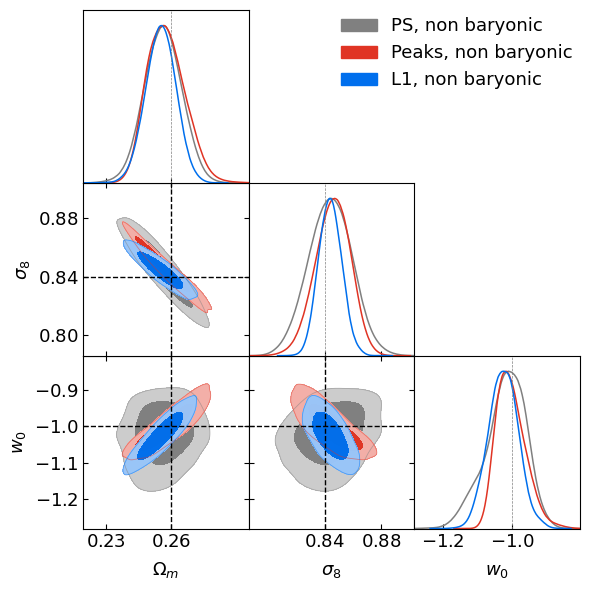

In [7]:
g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 16 
g.settings.axes_fontsize = 16
g.settings.lab_fontsize = 16

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([PS_full_nobar_sub, peaks_nobar_sub, l1_nobar_sub], 
                filled=True,
                markers={label: val for label, val in zip(labels_subset, true_params_subset)},
                contour_lws=1.1,
                marker_args={'color': 'black', 'lw': 1.}
               )
# plt.savefig('/home/tersenov/software/bar_impact/plots/contours_PS_peaks_L1_nobar_vs_nobar.pdf', bbox_inches='tight', transparent=True)
plt.show()

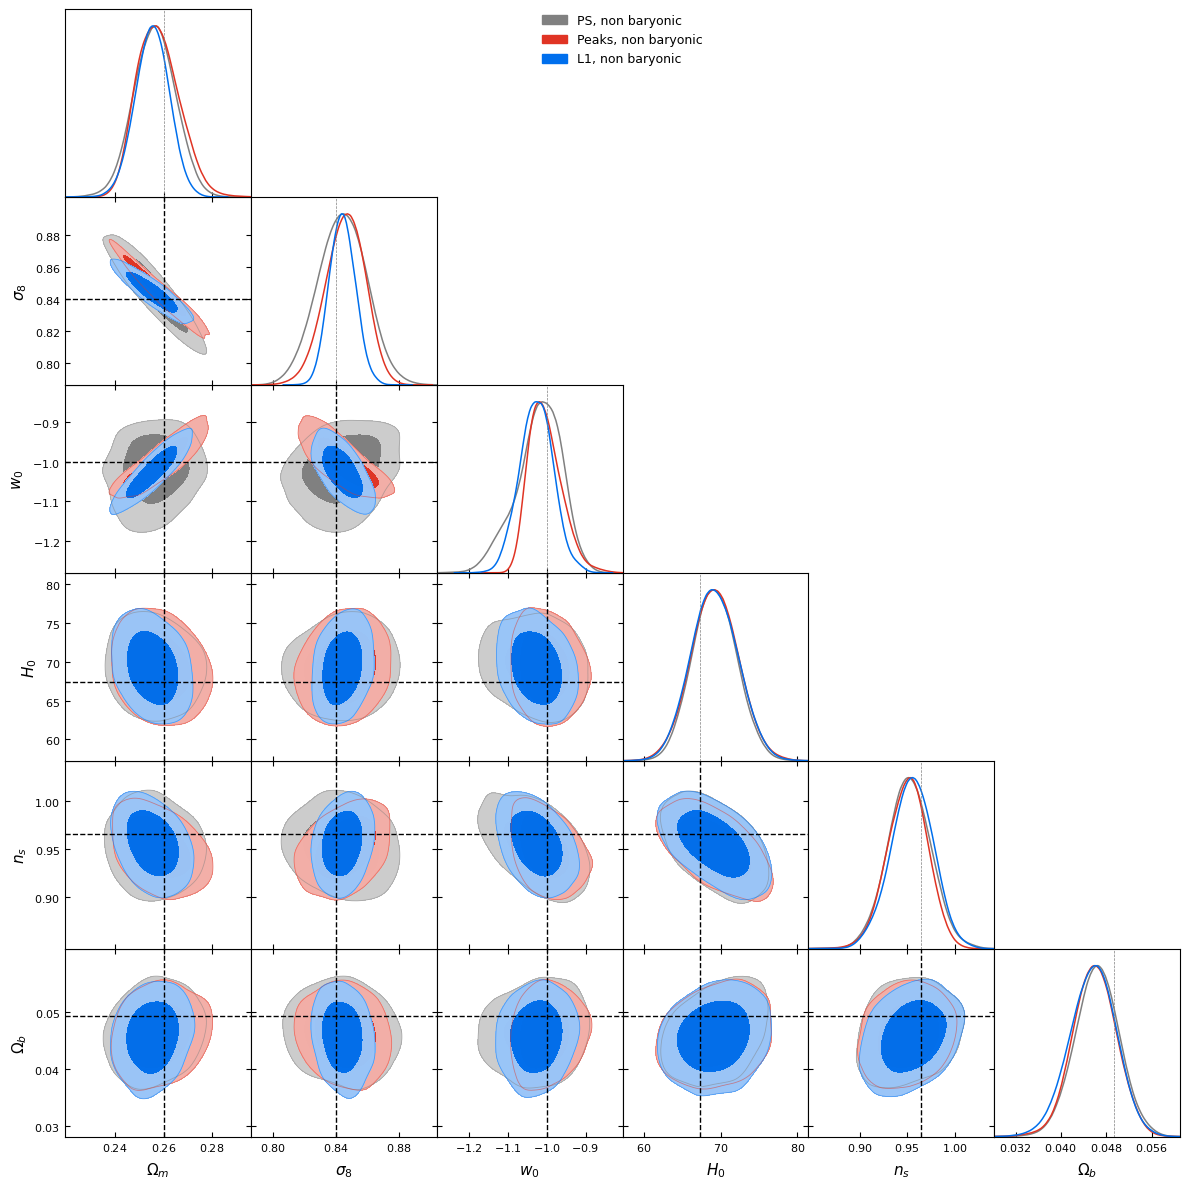

In [8]:
true_params = np.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([PS_full_nobar, peaks_nobar, l1_nobar],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

In [9]:
plt.rcParams['font.size'] = 18

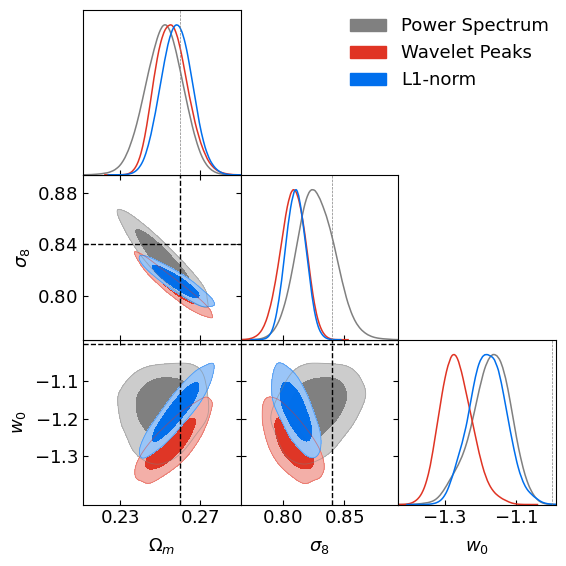

In [10]:
g = plots.get_subplot_plotter()

# # increase font size for better visibility in poster
g.settings.legend_fontsize = 16 
g.settings.axes_fontsize = 16
g.settings.lab_fontsize = 16


g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([PS_full_bar_sub, peaks_bar_sub, l1_bar_sub], 
                filled=True,
                markers={label: val for label, val in zip(labels_subset, true_params_subset)},
                contour_lws=1.1,
                marker_args={'color': 'black', 'lw': 1.}
               )

# save as pdf with transparent background
# plt.savefig('/home/tersenov/software/bar_impact/plots/contours_PS_peaks_L1_baryons_biased.pdf', bbox_inches='tight', transparent=True)

plt.show()

FoM New Code

In [9]:
# labels = ["Om", "s8", "w0", "H0", "ns", "Ob"]
param_names_fom = ["Om", "s8", "w0"]
print(f"--- Calculating FoM for the {len(param_names_fom)}D space: {param_names_fom} ---\n")
sample_sets = [PS_full_nobar, peaks_nobar, l1_nobar]

for samples in sample_sets:
    # 1. Get the indices of the desired parameters using the correct LaTeX strings
    param_indices = [param_names_fom.index(param) for param in param_names_fom]
    
    # 2. Get the full covariance matrix
    C_full = samples.getCov()
    
    # 3. Extract the marginalized covariance matrix (3x3 in this case)
    C_marg = C_full[param_indices][:, param_indices]
    
    # 4. Calculate the determinant
    det_C_marg = np.linalg.det(C_marg)
    
    # 5. Compute the FoM: FoM = 1 / sqrt(det(C_marg))
    # Note: If det_C_marg is very close to zero (perfect degeneracy), this will result in a very large FoM.
    FoM = 1.0 / np.sqrt(det_C_marg)
    
    print(f"FoM for {samples.label}: {FoM:.4f}")


--- Calculating FoM for the 3D space: ['Om', 's8', 'w0'] ---

FoM for PS, non baryonic: 1023613.7581
FoM for Peaks, non baryonic: 2273420.6829
FoM for L1, non baryonic: 3532740.7960


In [10]:
# labels = ["Om", "s8", "w0", "H0", "ns", "Ob"]
param_names_fom = ["Om", "s8", "w0"]
print(f"--- Calculating FoM for the {len(param_names_fom)}D space: {param_names_fom} ---\n")
sample_sets = [PS_full_bar, peaks_bar, l1_bar]

for samples in sample_sets:
    # 1. Get the indices of the desired parameters using the correct LaTeX strings
    param_indices = [param_names_fom.index(param) for param in param_names_fom]
    
    # 2. Get the full covariance matrix
    C_full = samples.getCov()
    
    # 3. Extract the marginalized covariance matrix (3x3 in this case)
    C_marg = C_full[param_indices][:, param_indices]
    
    # 4. Calculate the determinant
    det_C_marg = np.linalg.det(C_marg)
    
    # 5. Compute the FoM: FoM = 1 / sqrt(det(C_marg))
    # Note: If det_C_marg is very close to zero (perfect degeneracy), this will result in a very large FoM.
    FoM = 1.0 / np.sqrt(det_C_marg)
    
    print(f"FoM for {samples.label}: {FoM:.4f}")

--- Calculating FoM for the 3D space: ['Om', 's8', 'w0'] ---

FoM for Power Spectrum: 1015161.1799
FoM for Wavelet Peaks: 2194266.8849
FoM for L1-norm: 2875265.3073


FoM Old Code

In [25]:
# Compute the covariance matrix
cov_matrix_fom = np.cov(l1_nobar, rowvar=False)

# Compute the Fisher sub-matrix indices
param_indices = [param_names_fom.index(param) for param in param_names_fom]

# Extract the relevant rows and columns from the covariance matrix to form the Fisher sub-matrix
fisher_sub_matrix = cov_matrix_fom[np.ix_(param_indices, param_indices)]

# Compute the marginalised Fisher sub-matrix by inverting the covariance matrix
marginalised_fisher_sub_matrix = np.linalg.inv(fisher_sub_matrix)

# Compute the determinant of the marginalised Fisher sub-matrix
det_marginalised_fisher_sub_matrix = np.linalg.det(marginalised_fisher_sub_matrix)

# Compute the parameter space dimensionality
n_params = len(param_names_fom)

# Compute the Figure of Merit (FoM)
FoM = (det_marginalised_fisher_sub_matrix) ** (1/n_params)
FoM

23187.987636616097

# Unbiased contours

In [21]:
PS_auto_bar_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-540_r20_noisy_s0.26_npe.npy')
# PS_full_bar_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_auto_cross_nobaryons_vs_baryonified_bins1234_l30-1024_r20_noisy_s0.26_npe.npy')

In [22]:
l1_bar_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_nobaryons_vs_baryonified_bins1234_scales234_noisy_s0.26_new_normalization_npe.npy')
peaks_bar_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_pc_nobaryons_vs_baryonified_bins1234_scales234_noisy_s0.26_new_normalization_npe.npy')

In [23]:
labels = [r"$\Omega_{m}$", r"$\sigma_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

PS_auto_bar_unb = MCSamples(    
    samples=PS_auto_bar_unb,
    names=labels,
    label="Power Spectrum, cut"
)
# PS_full_bar = MCSamples(    
#     samples=PS_full_bar,    
#     names=labels,
#     label="PS auto+cross, baryonic"
# )

Removed no burn in


In [24]:

l1_bar_unb = MCSamples(    
    samples=l1_bar_unb,
    names=labels,
    label="L1, cut"
)

peaks_bar_unb = MCSamples(    
    samples=peaks_bar_unb,
    names=labels,
    label="Peaks, cut"
)


Removed no burn in
Removed no burn in


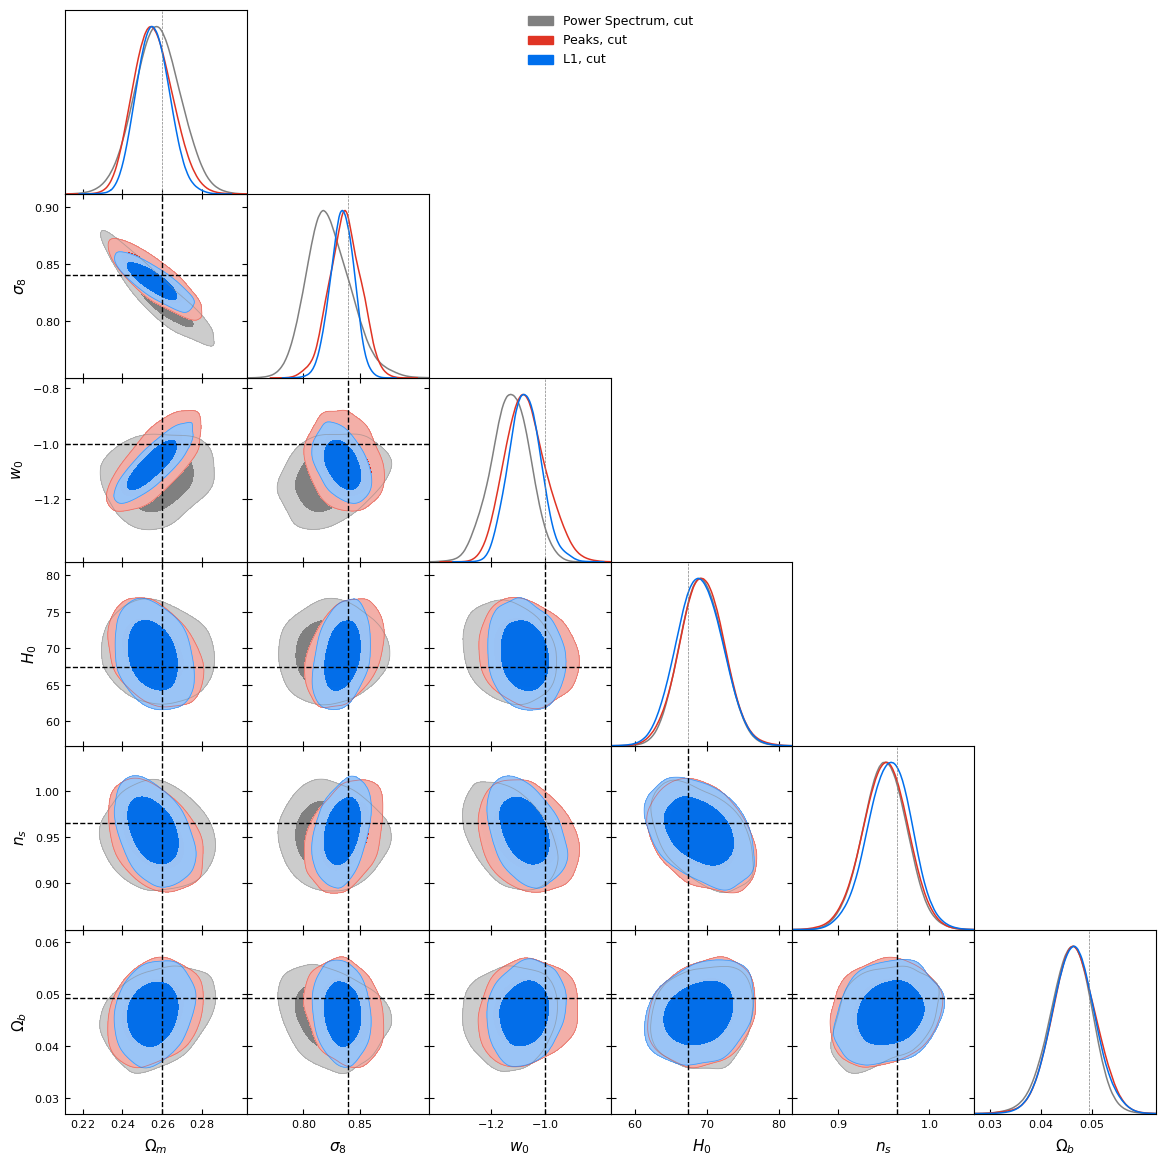

In [25]:
true_params = np.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([PS_auto_bar_unb, peaks_bar_unb, l1_bar_unb],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

Removed no burn in
Removed no burn in
Removed no burn in


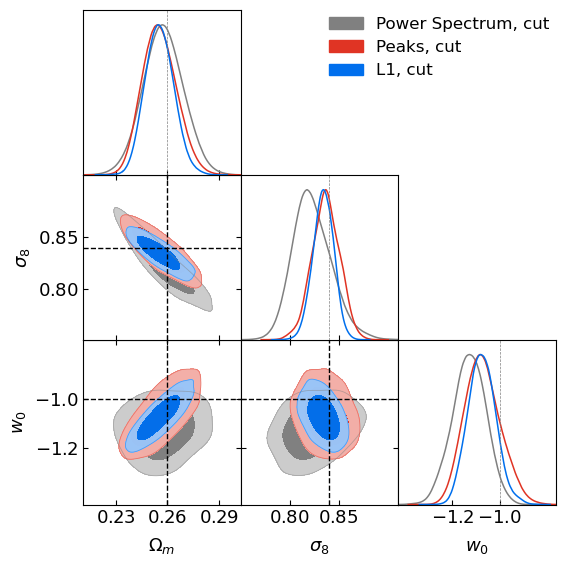

In [27]:
# Create subsets
PS_auto_bar_unb_sub = subset_mcsamples(PS_auto_bar_unb, subset_indices)
l1_bar_unb_sub = subset_mcsamples(l1_bar_unb, subset_indices)
peaks_bar_unb_sub = subset_mcsamples(peaks_bar_unb, subset_indices)

g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 15 
g.settings.axes_fontsize = 16
g.settings.lab_fontsize = 16


g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([PS_auto_bar_unb_sub, peaks_bar_unb_sub, l1_bar_unb_sub], 
                filled=True,
                markers={label: val for label, val in zip(labels_subset, true_params_subset)},
                contour_lws=1.1,
                marker_args={'color': 'black', 'lw': 1.}
               )

# save as svg
plt.savefig('/home/tersenov/software/bar_impact/plots/contours_PS_peaks_L1_baryons_unbiased.svg', bbox_inches='tight', transparent=True)

plt.show()


# BNT

In [55]:
PS_auto_bar_bnt = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bntbins1234_l30-1024_r20_noisy_s0.26_npe.npy')
PS_full_bar_bnt = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_bnt_ps_auto_cross_1-4_nobaryons_vs_nobaryons_bins1234_l30-1024_r20_noisy_s0.26_npe.npy')
PS_auto_bar_bnt_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bntbins1234_l30-400-1024-1024-1024_r20_noisy_s0.26_npe.npy')

In [56]:
l1_bar_bnt = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_nobaryons_vs_baryonified_bntbins1234_scales1234_noisy_s0.26_new_normalization_binrange5-35_npe.npy')
peaks_bar_bnt = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_bnt_pc_nobaryons_vs_baryonified_bntbins1234_scales1234_noisy_s0.26_new_normalization_npe.npy')

In [57]:
PS_auto_bar_bnt = MCSamples(    
    samples=PS_auto_bar_bnt,
    names=labels,
    label="PS, BNT"
)
PS_auto_bar_bnt_unb = MCSamples(
    samples=PS_auto_bar_bnt_unb,
    names=labels,
    label="PS, BNT, unbiased"
)
PS_full_bar_bnt = MCSamples(
    samples=PS_full_bar_bnt,
    names=labels,
    label="PS, auto&cross, BNT"
)

l1_bar_bnt = MCSamples(    
    samples=l1_bar_bnt,
    names=labels,
    label="L1, BNT"
)

peaks_bar_bnt = MCSamples(    
    samples=peaks_bar_bnt,
    names=labels,
    label="Peaks, BNT"
)


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


Removed no burn in
Removed no burn in
Removed no burn in


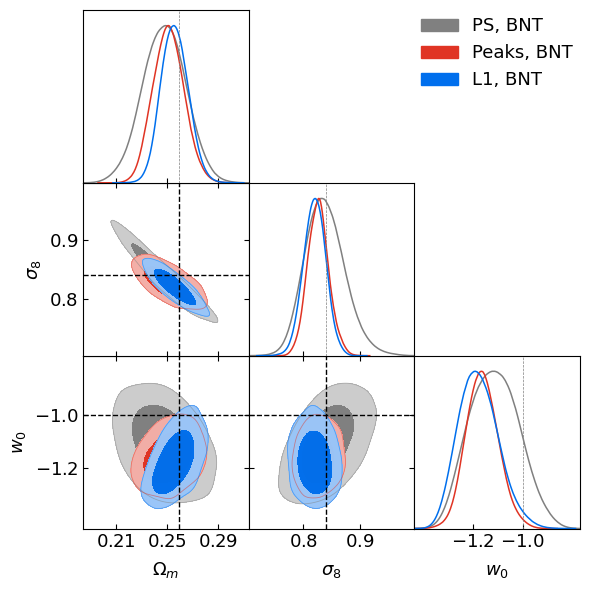

In [58]:
# Create subsets
PS_auto_bar_bnt_sub = subset_mcsamples(PS_auto_bar_bnt, subset_indices)
l1_bar_bnt_sub = subset_mcsamples(l1_bar_bnt, subset_indices)
peaks_bar_bnt_sub = subset_mcsamples(peaks_bar_bnt, subset_indices)

g = plots.get_subplot_plotter()
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99  

g.settings.legend_fontsize = 16 
g.settings.axes_fontsize = 16
g.settings.lab_fontsize = 16

g.triangle_plot([PS_auto_bar_bnt_sub, peaks_bar_bnt_sub, l1_bar_bnt_sub], 
                filled=True,
                markers={label: val for label, val in zip(labels_subset, true_params_subset)},
                contour_lws=1.1,
                marker_args={'color': 'black', 'lw': 1.}
               )
# save as pdf
# plt.savefig('/home/tersenov/software/bar_impact/plots/contours_PS_peaks_L1_baryons_BNT.pdf', bbox_inches='tight', transparent=True)
plt.show()

Removed no burn in
Removed no burn in


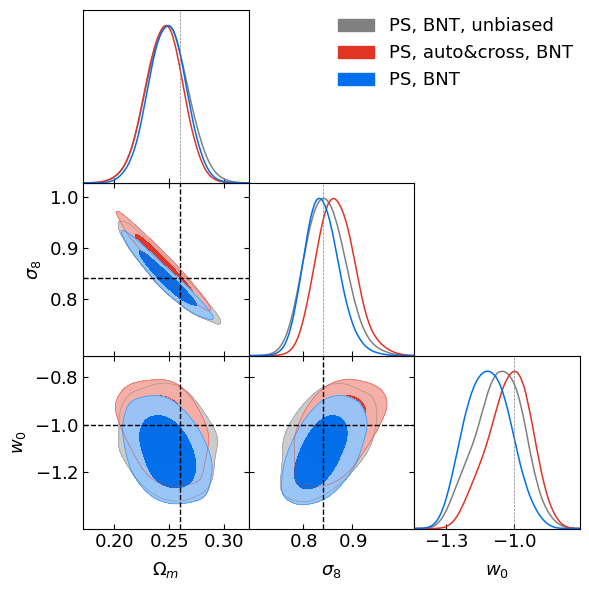

In [59]:
PS_auto_bar_bnt_unb_sub = subset_mcsamples(PS_auto_bar_bnt_unb, subset_indices)
PS_full_bar_bnt_sub = subset_mcsamples(PS_full_bar_bnt, subset_indices)

g = plots.get_subplot_plotter()
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99  

g.settings.legend_fontsize = 16 
g.settings.axes_fontsize = 16
g.settings.lab_fontsize = 16

g.triangle_plot([PS_auto_bar_bnt_unb_sub, PS_full_bar_bnt_sub, PS_auto_bar_bnt_sub], 
                filled=True,
                markers={label: val for label, val in zip(labels_subset, true_params_subset)},
                contour_lws=1.1,
                marker_args={'color': 'black', 'lw': 1.}
               )
# save as pdf
# plt.savefig('/home/tersenov/software/bar_impact/plots/contours_PS_peaks_L1_baryons_BNT.pdf', bbox_inches='tight', transparent=True)
plt.show()

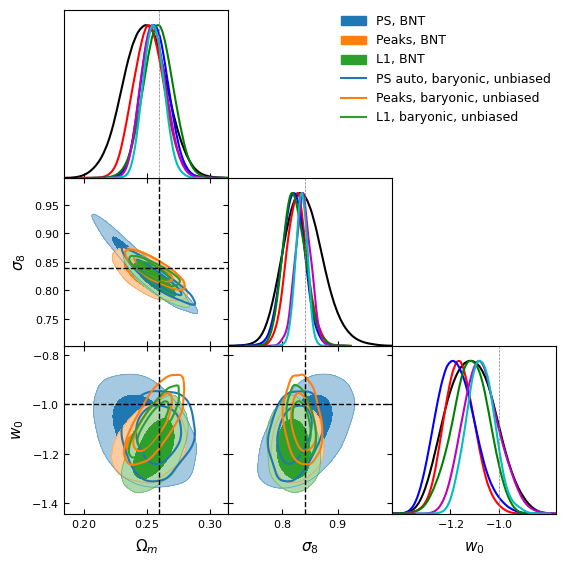

In [29]:
g = plots.get_subplot_plotter()
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

line_arguments = [
    {'lw': 1.5, 'ls': '-'},
    {'lw': 1.5, 'ls': '-'},
    {'lw': 1.5, 'ls': '-'},
    {'lw': .1, 'ls': '-'},
    {'lw': .1, 'ls': '-'},
    {'lw': .1, 'ls': '-'},
]

color_scheme = ['C0', 'C1', 'C2', 'C0', 'C1', 'C2']

# Change 'filled' to a list: True for the first sample, False for the second
g.triangle_plot([PS_auto_bar_bnt_sub, peaks_bar_bnt_sub, l1_bar_bnt_sub, PS_auto_bar_unb_sub, peaks_bar_unb_sub, l1_bar_unb_sub],
                filled=[True, True, True, False, False, False],  # <-- This is the key change
                markers={label: val for label, val in zip(labels_subset, true_params_subset)},
                contour_lws=1.5,
                marker_args={'color': 'black', 'lw': 1.},
                line_args=line_arguments,
                colors=color_scheme,
               )

# save as pdf
plt.show()

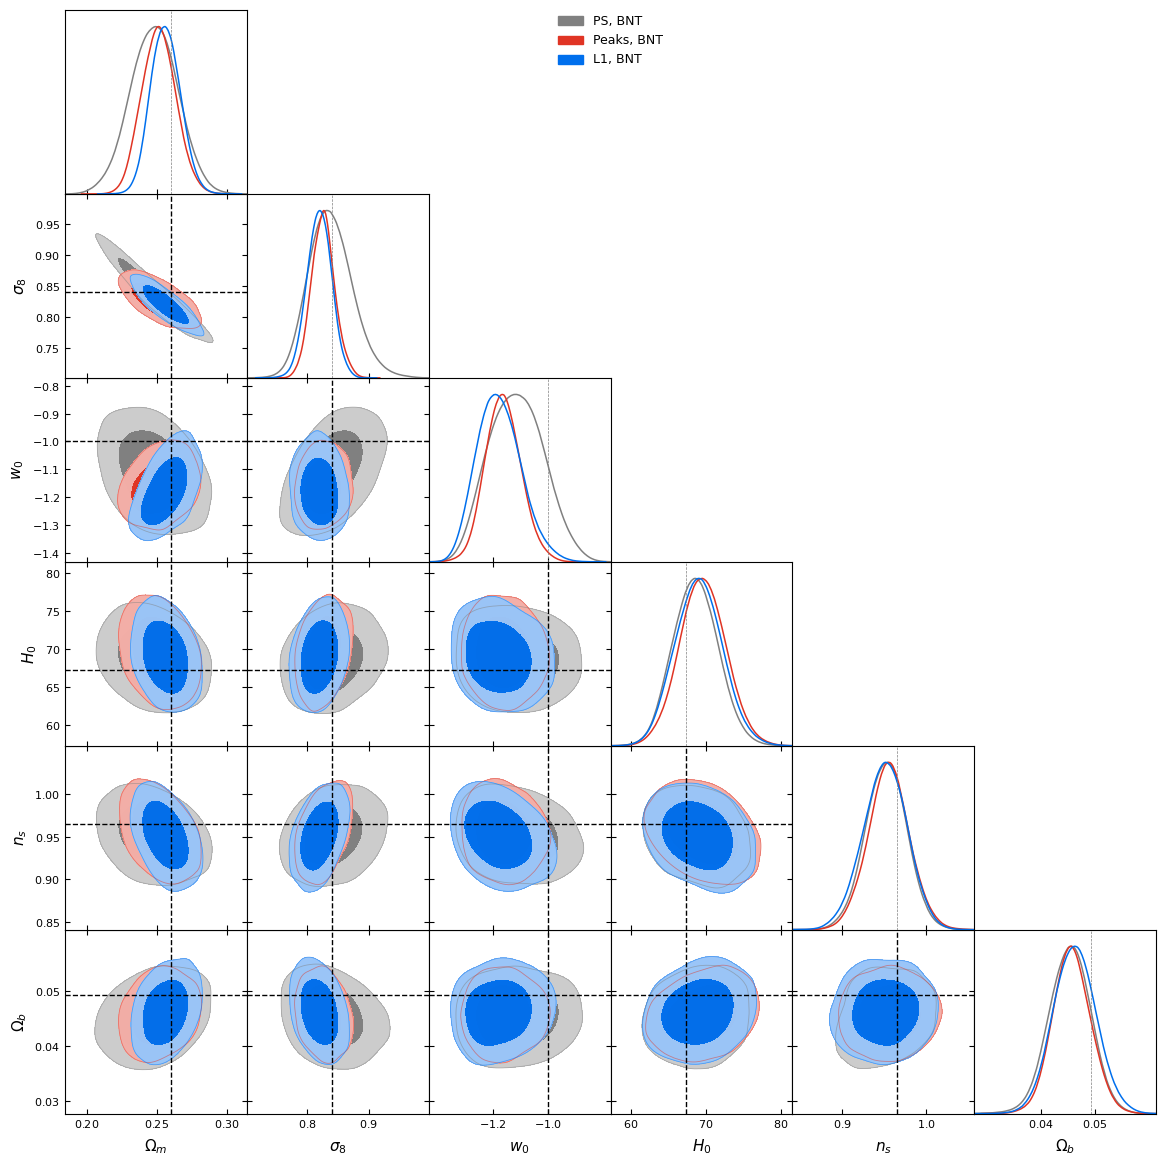

In [30]:
true_params = np.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([PS_auto_bar_bnt, peaks_bar_bnt, l1_bar_bnt],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

## Figures of Merit (FoM)

In [48]:
# labels = ["Om", "s8", "w0", "H0", "ns", "Ob"]
param_names_fom = ["Om", "s8", "w0"]
print(f"--- Calculating FoM for the {len(param_names_fom)}D space: {param_names_fom} ---\n")
sample_sets = [PS_full_nobar, peaks_nobar, l1_nobar]

for samples in sample_sets:
    # 1. Get the indices of the desired parameters using the correct LaTeX strings
    param_indices = [param_names_fom.index(param) for param in param_names_fom]
    
    # 2. Get the full covariance matrix
    C_full = samples.getCov()
    
    # 3. Extract the marginalized covariance matrix (3x3 in this case)
    C_marg = C_full[param_indices][:, param_indices]
    
    # 4. Calculate the determinant
    det_C_marg = np.linalg.det(C_marg)
    
    # 5. Compute the FoM: FoM = 1 / sqrt(det(C_marg))
    # Note: If det_C_marg is very close to zero (perfect degeneracy), this will result in a very large FoM.
    FoM = 1.0 / np.sqrt(det_C_marg)
    
    print(f"FoM for {samples.label}: {FoM:.4f}")


--- Calculating FoM for the 3D space: ['Om', 's8', 'w0'] ---

FoM for PS, non baryonic: 1023613.7581
FoM for Peaks, non baryonic: 2273420.6829
FoM for L1, non baryonic: 3532740.7960


In [62]:
# labels = ["Om", "s8", "w0", "H0", "ns", "Ob"]
param_names_fom = ["Om", "s8", "w0"]
print(f"--- Calculating FoM for the {len(param_names_fom)}D space: {param_names_fom} ---\n")

sample_sets_groups = [[PS_full_nobar, peaks_nobar, l1_nobar], [PS_full_bar, peaks_bar, l1_bar], [PS_auto_bar_unb, peaks_bar_unb, l1_bar_unb], [PS_auto_bar_bnt, peaks_bar_bnt, l1_bar_bnt]]
sample_sets_names = ["No Baryons, no scale cuts", "With Baryons, no scale cuts", "With Baryons, unbiased", "With Baryons, BNT"]

for group, name in zip(sample_sets_groups, sample_sets_names):
    sample_sets = group
    print('*',name)
    for samples in sample_sets:

        # 1. Get the indices of the desired parameters using the correct LaTeX strings
        param_indices = [param_names_fom.index(param) for param in param_names_fom]
        
        # 2. Get the full covariance matrix
        C_full = samples.getCov()
        
        # 3. Extract the marginalized covariance matrix (3x3 in this case)
        C_marg = C_full[param_indices][:, param_indices]
        
        # 4. Calculate the determinant
        det_C_marg = np.linalg.det(C_marg)
        
        # 5. Compute the FoM: FoM = 1 / sqrt(det(C_marg))
        # Note: If det_C_marg is very close to zero (perfect degeneracy), this will result in a very large FoM.
        FoM = 1.0 / np.sqrt(det_C_marg)
        
        print(f"FoM for {samples.label}: {FoM:.4f}")


--- Calculating FoM for the 3D space: ['Om', 's8', 'w0'] ---

* No Baryons, no scale cuts
FoM for PS, non baryonic: 1023613.7581
FoM for Peaks, non baryonic: 2273420.6829
FoM for L1, non baryonic: 3532740.7960
* With Baryons, no scale cuts
FoM for Power Spectrum: 1015161.1799
FoM for Wavelet Peaks: 2194266.8849
FoM for L1-norm: 2875265.3073
* With Baryons, unbiased
FoM for PS auto, baryonic, unbiased: 532787.7689
FoM for Peaks, baryonic, unbiased: 606726.9729
FoM for L1, baryonic, unbiased: 1313504.0309
* With Baryons, BNT
FoM for PS, BNT: 80571.6062
FoM for Peaks, BNT: 95921.2833
FoM for L1, BNT: 187577.2800


<!-- make a table with the FOM values -->
| Data Set | Analysis Method | FoM ($\Omega_m, \sigma_8, w_0$) |
| :--- | :--- | :--- |
| **No Baryons, No Scale Cuts** | Power Spectrum (PS) | $1,023,613.76$ |
| | Wavelet Peaks | $2,273,420.68$ |
| | L1-norm | $3,532,740.80$ |
| **With Baryons, No Scale Cuts** | Power Spectrum | $1,015,161.18$ |
| | Wavelet Peaks | $2,194,266.88$ |
| | L1-norm | $2,875,265.31$ |
| **With Baryons, Unbiased** | PS auto, baryonic | $532,787.77$ |
| | Wavelet Peaks | $606,726.97$ |
| | L1-norm | $1,313,504.03$ |
| **With Baryons, BNT** | Power Spectrum (PS) | $80,571.61$ |
| | Wavelet Peaks | $95,921.28$ |
| | L1-norm | $187,577.28$ |

| Statistic | FoM ($\Omega_m, \sigma_8, w_0$) |
|:--- | :--- |
| Power Spectrum | $102$ |
| Wavelet Peaks | $227$ |
| L1-norm | $353$ |

# New vs old PS

In [61]:
PS_old = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bin1_l30-1024_r10_noisy_s0.26_npe.npy')
PS_new = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_nobaryons_bin1_l30-1024_r20_noisy_s0.26_npe_new.npy')

In [62]:
PS_old = MCSamples(    
    samples=PS_old,
    names=labels,
    label="PS_old"
)
PS_new = MCSamples(
    samples=PS_new,
    names=labels,
    label="PS_new"
)

Removed no burn in
Removed no burn in


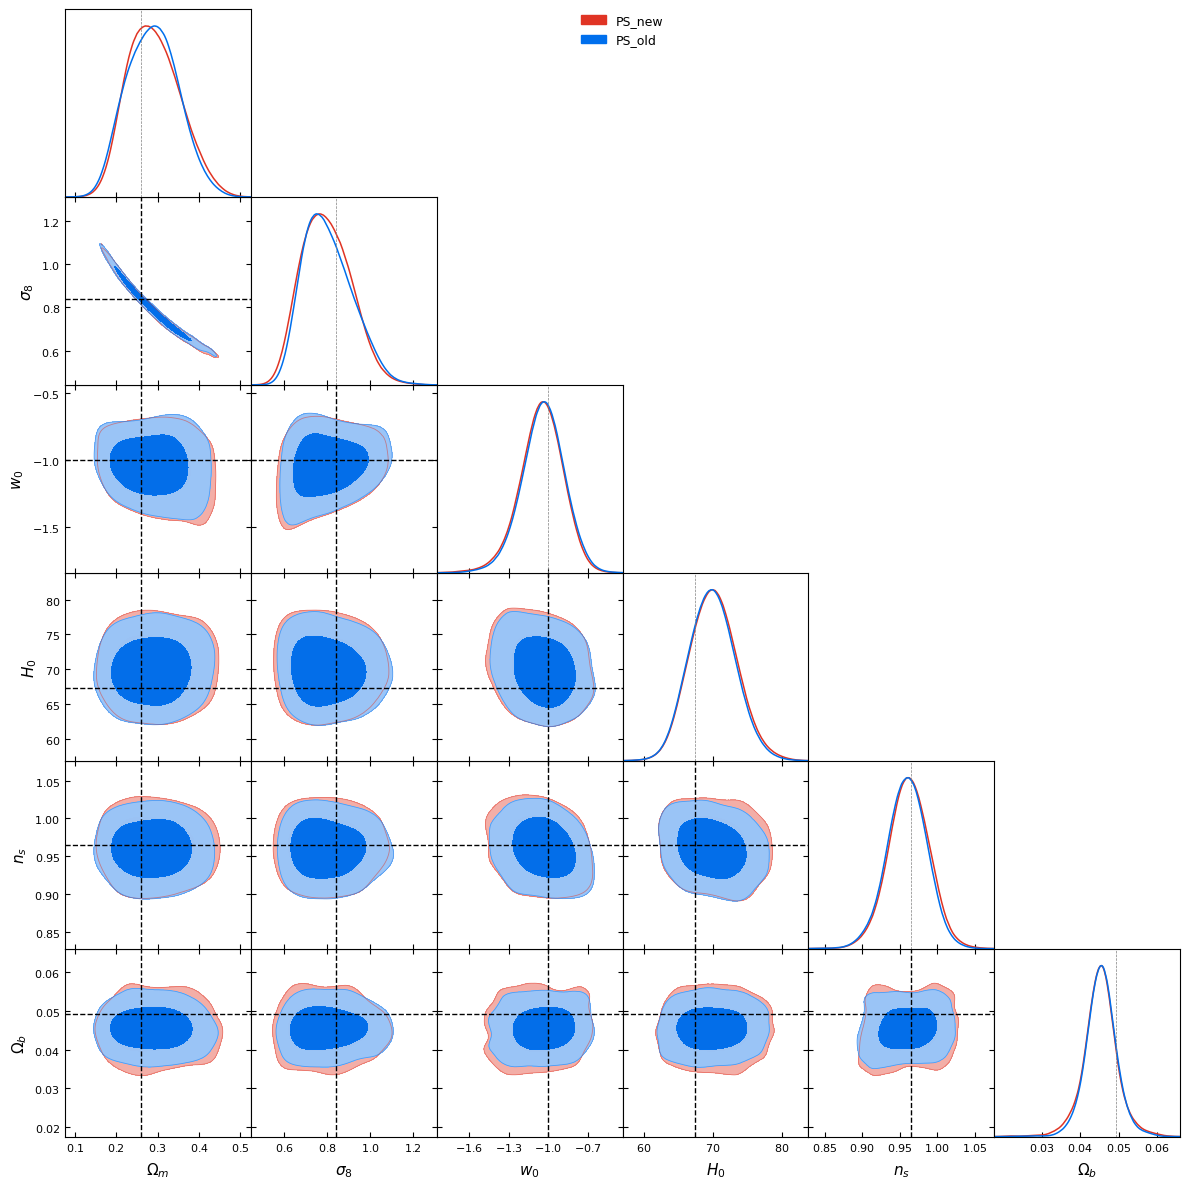

In [63]:
true_params = np.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([PS_new, PS_old],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

# Statistics

## Power Spectrum

In [3]:
fid_bar_bin1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_baryonified_bin1_noisy_s0.26.npy')
fid_nobar_bin1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_nobaryons_bin1_noisy_s0.26.npy')

fid_bar_bin2 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_baryonified_bin2_noisy_s0.26.npy')
fid_nobar_bin2 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_nobaryons_bin2_noisy_s0.26.npy')

fid_bar_bin3 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_baryonified_bin3_noisy_s0.26.npy')
fid_nobar_bin3 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_nobaryons_bin3_noisy_s0.26.npy')

fid_bar_bin4 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_baryonified_bin4_noisy_s0.26.npy')
fid_nobar_bin4 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_nobaryons_bin4_noisy_s0.26.npy')

In [4]:
fid_bar_bin1.shape, fid_nobar_bin1.shape

((200, 1025), (200, 1025))

In [5]:
# remove first element from each array (l=0)
fid_bar_bin1 = fid_bar_bin1[:, 30:]
fid_nobar_bin1 = fid_nobar_bin1[:, 30:]
fid_bar_bin2 = fid_bar_bin2[:, 30:]
fid_nobar_bin2 = fid_nobar_bin2[:, 30:]
fid_bar_bin3 = fid_bar_bin3[:, 30:]
fid_nobar_bin3 = fid_nobar_bin3[:, 30:]
fid_bar_bin4 = fid_bar_bin4[:, 30:]
fid_nobar_bin4 = fid_nobar_bin4[:, 30:]

In [6]:
# rebin each array to have 20 elements (logarithmic bins)
def rebin(arr, new_size=20):
    old_size = arr.shape[1]
    log_bins = np.logspace(np.log10(30), np.log10(1024), new_size + 1).astype(int)
    rebinned = np.zeros((arr.shape[0], new_size))
    for i in range(new_size):
        rebinned[:, i] = arr[:, log_bins[i]:log_bins[i+1]].mean(axis=1)
    return rebinned

In [7]:
new_size=10
fid_bar_bin1 = rebin(fid_bar_bin1, new_size)
fid_nobar_bin1 = rebin(fid_nobar_bin1, new_size)
fid_bar_bin2 = rebin(fid_bar_bin2, new_size)
fid_nobar_bin2 = rebin(fid_nobar_bin2, new_size)
fid_bar_bin3 = rebin(fid_bar_bin3, new_size)
fid_nobar_bin3 = rebin(fid_nobar_bin3, new_size)
fid_bar_bin4 = rebin(fid_bar_bin4, new_size)
fid_nobar_bin4 = rebin(fid_nobar_bin4, new_size)

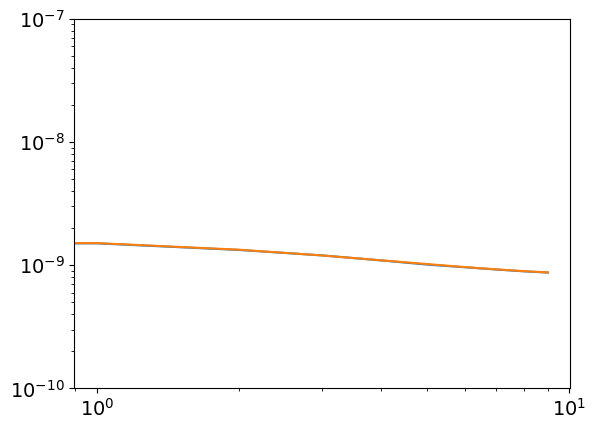

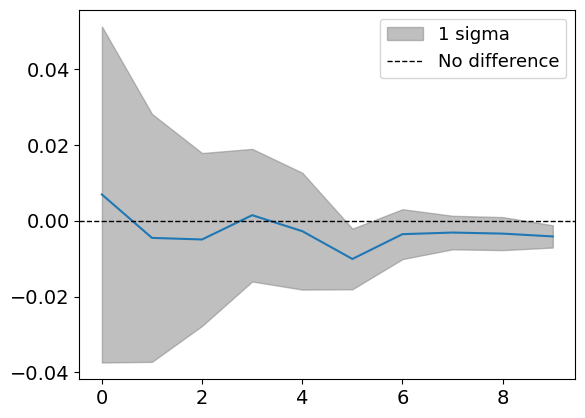

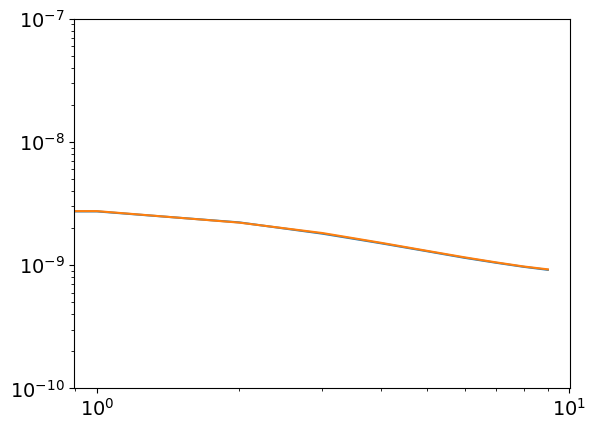

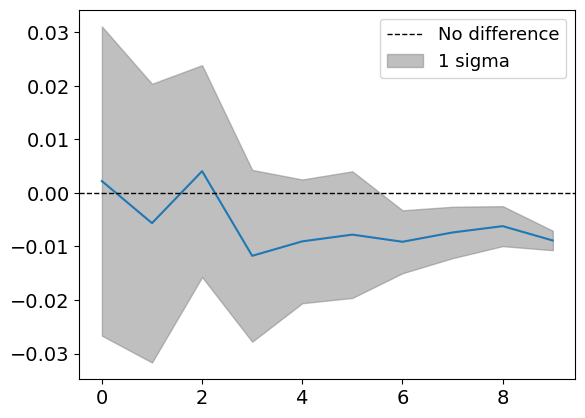

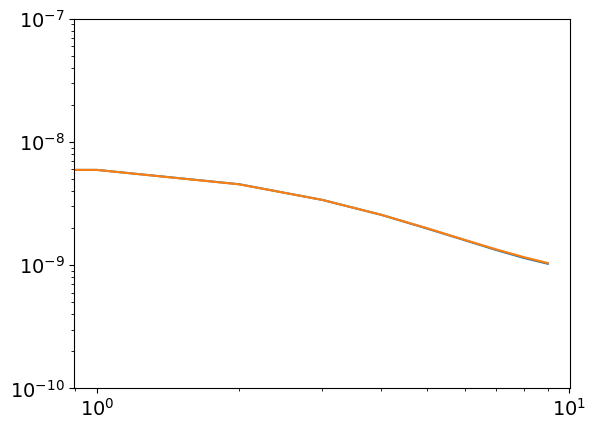

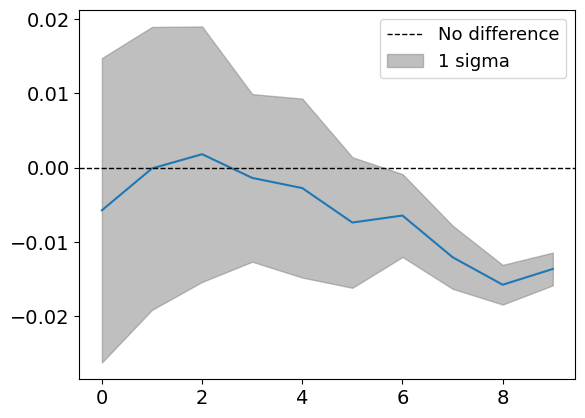

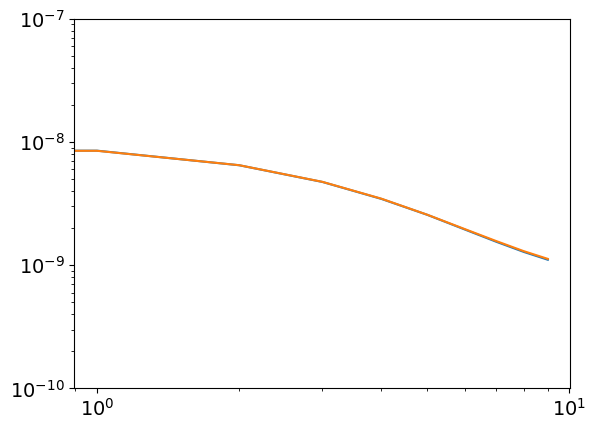

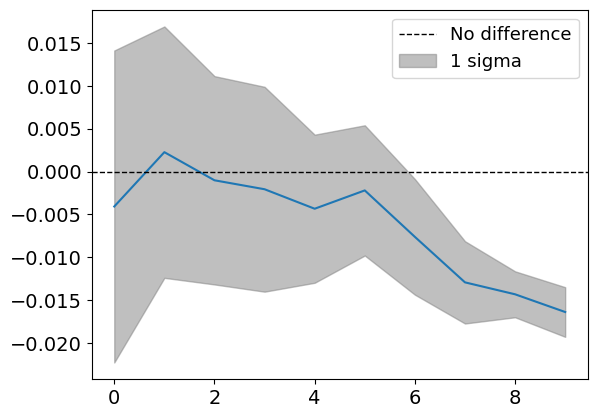

In [31]:
plt.loglog(np.mean(fid_bar_bin1, axis=0))
plt.loglog(np.mean(fid_nobar_bin1, axis=0))
plt.ylim (1e-10, 1e-7)
plt.show()

# plot fractional difference
frac_diff1 = np.mean(fid_bar_bin1 - fid_nobar_bin1, axis=0) / np.mean(fid_nobar_bin1, axis=0)
plt.plot(frac_diff1)
# calculate the standard deviation of the fractional difference across the different realizations and plot as shaded region
std_fractional_diff_bin1 = np.std((fid_bar_bin1 - fid_nobar_bin1) / fid_nobar_bin1, axis=0)
plt.fill_between(np.arange(len(std_fractional_diff_bin1)), frac_diff1-std_fractional_diff_bin1, frac_diff1+std_fractional_diff_bin1, color='gray', alpha=0.5, label='1 sigma')
plt.axhline(0, color='black', linestyle='--', lw=1, label='No difference')
plt.legend()
# plt.ylim(-0.1, 0.1)
plt.show()

plt.loglog(np.mean(fid_bar_bin2, axis=0))
plt.loglog(np.mean(fid_nobar_bin2, axis=0))
plt.ylim (1e-10, 1e-7)
plt.show()

# plot fractional difference
frac_diff2 = np.mean(fid_bar_bin2 - fid_nobar_bin2, axis=0) / np.mean(fid_nobar_bin2, axis=0)
plt.plot(frac_diff2)
plt.axhline(0, color='black', linestyle='--', lw=1, label='No difference')
std_fractional_diff_bin2 = np.std((fid_bar_bin2 - fid_nobar_bin2) / fid_nobar_bin2, axis=0)
plt.fill_between(np.arange(len(std_fractional_diff_bin2)), frac_diff2-std_fractional_diff_bin2, frac_diff2+std_fractional_diff_bin2, color='gray', alpha=0.5, label='1 sigma')
plt.legend()
# plt.ylim(-0.1, 0.1)
plt.show()

plt.loglog(np.mean(fid_bar_bin3, axis=0))
plt.loglog(np.mean(fid_nobar_bin3, axis=0))
plt.ylim (1e-10, 1e-7)
plt.show()

# plot fractional difference
frac_diff3 = np.mean(fid_bar_bin3 - fid_nobar_bin3, axis=0) / np.mean(fid_nobar_bin3, axis=0)
plt.plot(frac_diff3)
plt.axhline(0, color='black', linestyle='--', lw=1, label='No difference')
std_fractional_diff_bin3 = np.std((fid_bar_bin3 - fid_nobar_bin3) / fid_nobar_bin3, axis=0)
plt.fill_between(np.arange(len(std_fractional_diff_bin3)), frac_diff3-std_fractional_diff_bin3, frac_diff3+std_fractional_diff_bin3, color='gray', alpha=0.5, label='1 sigma')
plt.legend()
# plt.ylim(-0.1, 0.1)
plt.show()

plt.loglog(np.mean(fid_bar_bin4, axis=0))
plt.loglog(np.mean(fid_nobar_bin4, axis=0))
plt.ylim (1e-10, 1e-7)
plt.show()

# plot fractional difference
frac_diff4 = np.mean(fid_bar_bin4 - fid_nobar_bin4, axis=0) / np.mean(fid_nobar_bin4, axis=0)
plt.plot(frac_diff4)
plt.axhline(0, color='black', linestyle='--', lw=1, label='No difference')
std_fractional_diff_bin4 = np.std((fid_bar_bin4 - fid_nobar_bin4) / fid_nobar_bin4, axis=0)
plt.fill_between(np.arange(len(std_fractional_diff_bin4)), frac_diff4-std_fractional_diff_bin4, frac_diff4+std_fractional_diff_bin4, color='gray', alpha=0.5, label='1 sigma')
plt.legend()
# plt.ylim(-0.1, 0.1)
plt.show()

In [9]:
ells = np.arange(1024)[30:]
ells_rebinned = np.arange(30, 1024, 100)

In [10]:
ells_rebinned.shape

(10,)

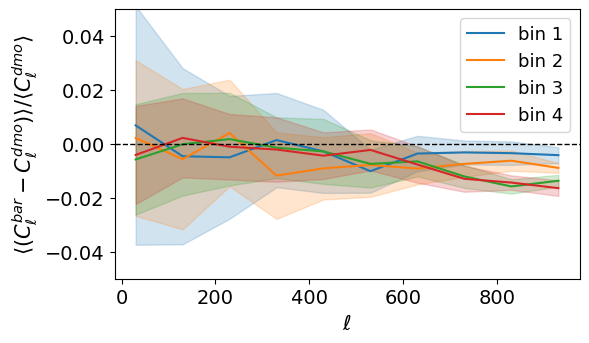

In [10]:
# plot fractional difference
frac_diff1 = np.mean(fid_bar_bin1 - fid_nobar_bin1, axis=0) / np.mean(fid_nobar_bin1, axis=0)
std_fractional_diff_bin1 = np.std((fid_bar_bin1 - fid_nobar_bin1) / fid_nobar_bin1, axis=0)
frac_diff2 = np.mean(fid_bar_bin2 - fid_nobar_bin2, axis=0) / np.mean(fid_nobar_bin2, axis=0)
std_fractional_diff_bin2 = np.std((fid_bar_bin2 - fid_nobar_bin2) / fid_nobar_bin2, axis=0)
frac_diff3 = np.mean(fid_bar_bin3 - fid_nobar_bin3, axis=0) / np.mean(fid_nobar_bin3, axis=0)
std_fractional_diff_bin3 = np.std((fid_bar_bin3 - fid_nobar_bin3) / fid_nobar_bin3, axis=0)
frac_diff4 = np.mean(fid_bar_bin4 - fid_nobar_bin4, axis=0) / np.mean(fid_nobar_bin4, axis=0)
std_fractional_diff_bin4 = np.std((fid_bar_bin4 - fid_nobar_bin4) / fid_nobar_bin4, axis=0)

plt.figure(figsize=(6,3.5))

# change the size of the legend
plt.rcParams['legend.fontsize'] = 13
# change the size of the axes labels
plt.rcParams['axes.labelsize'] = 15
# change the size of the ticks
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# calculate the standard deviation of the fractional difference across the different realizations and plot as shaded region
plt.fill_between(ells_rebinned, frac_diff1-std_fractional_diff_bin1, frac_diff1+std_fractional_diff_bin1, color='C0', alpha=0.2)
plt.fill_between(ells_rebinned, frac_diff2-std_fractional_diff_bin2, frac_diff2+std_fractional_diff_bin2, color='C1', alpha=0.2)
plt.fill_between(ells_rebinned, frac_diff3-std_fractional_diff_bin3, frac_diff3+std_fractional_diff_bin3, color='C2', alpha=0.2)
plt.fill_between(ells_rebinned, frac_diff4-std_fractional_diff_bin4, frac_diff4+std_fractional_diff_bin4, color='C3', alpha=0.2)

plt.plot(ells_rebinned, frac_diff1, label='bin 1')
plt.plot(ells_rebinned, frac_diff2, label='bin 2')
plt.plot(ells_rebinned, frac_diff3, label='bin 3')
plt.plot(ells_rebinned, frac_diff4, label='bin 4')

plt.axhline(0, color='black', linestyle='--', lw=1)
plt.xlabel(r'$\ell$')
# plt.ylabel(r'$\langle \Delta C_\ell \rangle / \langle C_\ell \rangle$')
plt.ylabel(r'$\langle (C_\ell^{bar} - C_\ell^{dmo})\rangle / \langle C_\ell^{dmo} \rangle$')
plt.legend()
plt.ylim(-0.05, 0.05)
plt.savefig('/home/tersenov/software/bar_impact/plots/frac_diff_ps.pdf', transparent=True, bbox_inches='tight')
plt.show()

## Peaks

In [44]:
fid_bar_bin1_pc = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_peak_counts_fiducial_baryonified_bin1_noisy_s0.26_new_normalization.npy')
fid_nobar_bin1_pc = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_peak_counts_fiducial_nobaryons_bin1_noisy_s0.26_new_normalization.npy')

fid_bar_bin2_pc = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_peak_counts_fiducial_baryonified_bin2_noisy_s0.26_new_normalization.npy')
fid_nobar_bin2_pc = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_peak_counts_fiducial_nobaryons_bin2_noisy_s0.26_new_normalization.npy')

fid_bar_bin3_pc = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_peak_counts_fiducial_baryonified_bin3_noisy_s0.26_new_normalization.npy')
fid_nobar_bin3_pc = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_peak_counts_fiducial_nobaryons_bin3_noisy_s0.26_new_normalization.npy')

fid_bar_bin4_pc = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_peak_counts_fiducial_baryonified_bin4_noisy_s0.26_new_normalization.npy')
fid_nobar_bin4_pc = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_peak_counts_fiducial_nobaryons_bin4_noisy_s0.26_new_normalization.npy') 

In [45]:
fid_bar_bin1_pc.shape, fid_nobar_bin1_pc.shape

((200, 5, 40), (200, 5, 40))

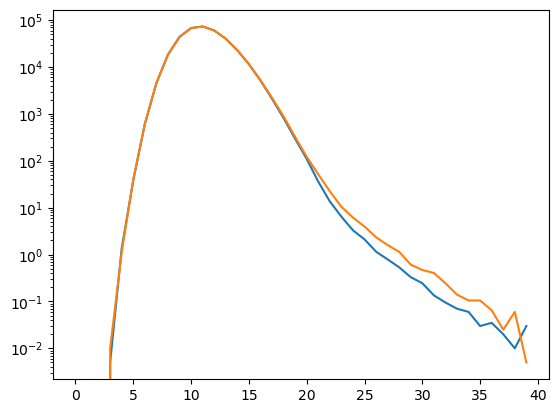

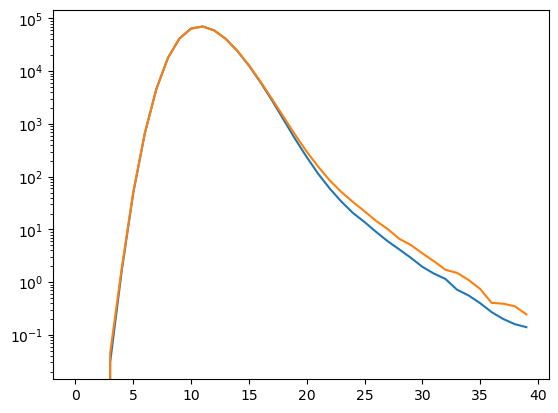

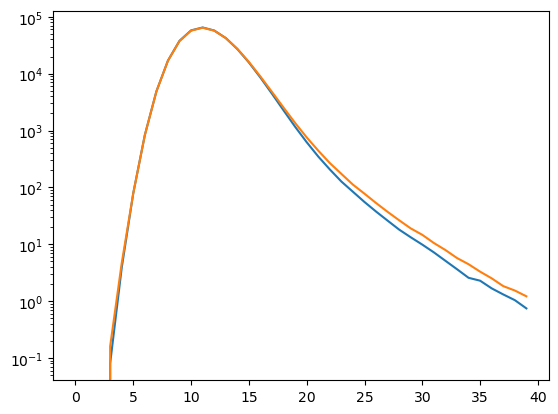

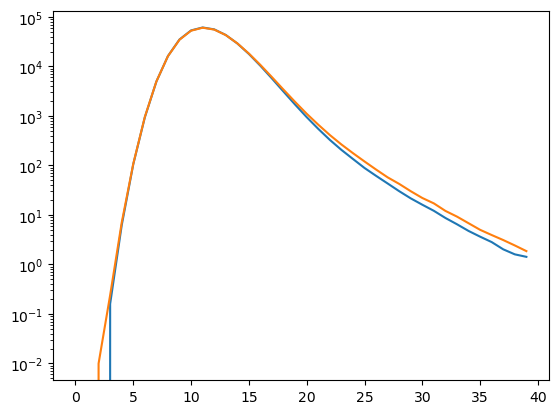

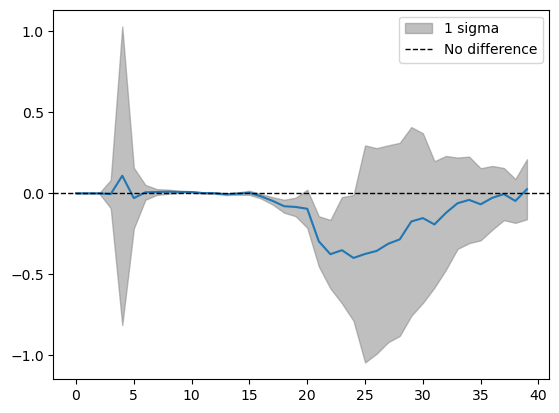

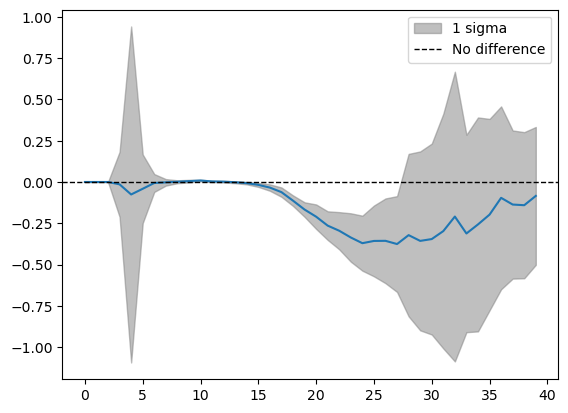

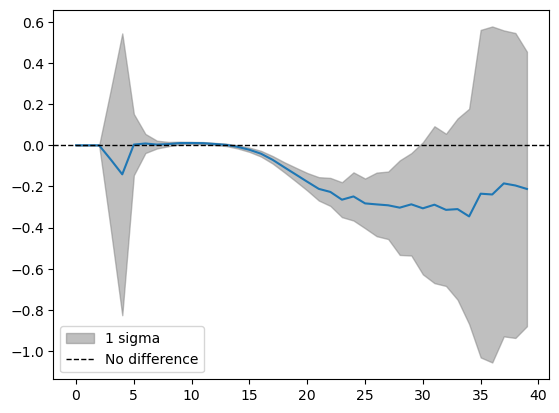

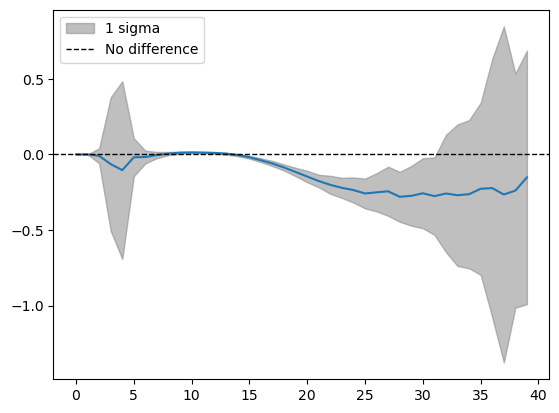

In [34]:
plt.plot(np.mean(fid_bar_bin1_pc[:,0,:], axis=0))
plt.plot(np.mean(fid_nobar_bin1_pc[:,0,:], axis=0))
plt.yscale('log')
plt.show()
plt.plot(np.mean(fid_bar_bin2_pc[:,0,:], axis=0))
plt.plot(np.mean(fid_nobar_bin2_pc[:,0,:], axis=0))
plt.yscale('log')
plt.show()
plt.plot(np.mean(fid_bar_bin3_pc[:,0,:], axis=0))
plt.plot(np.mean(fid_nobar_bin3_pc[:,0,:], axis=0))
plt.yscale('log')
plt.show()
plt.plot(np.mean(fid_bar_bin4_pc[:,0,:], axis=0))
plt.plot(np.mean(fid_nobar_bin4_pc[:,0,:], axis=0))
plt.yscale('log')
plt.show()

frac_diff1_pc = np.mean(fid_bar_bin1_pc[:,0,:] - fid_nobar_bin1_pc[:,0,:], axis=0) / (np.mean(fid_nobar_bin1_pc[:,0,:], axis=0) + 1)
plt.plot(frac_diff1_pc)
std_fractional_diff_bin1_pc = np.std((fid_bar_bin1_pc[:,0,:] - fid_nobar_bin1_pc[:,0,:]) / (fid_nobar_bin1_pc[:,0,:]+ 1), axis=0)
plt.fill_between(np.arange(len(std_fractional_diff_bin1_pc)), frac_diff1_pc-std_fractional_diff_bin1_pc, frac_diff1_pc+std_fractional_diff_bin1_pc, color='gray', alpha=0.5, label='1 sigma')
plt.axhline(0, color='black', linestyle='--', lw=1, label='No difference')
plt.legend()
plt.show()

frac_diff2_pc = np.mean(fid_bar_bin2_pc[:,0,:] - fid_nobar_bin2_pc[:,0,:], axis=0) / (np.mean(fid_nobar_bin2_pc[:,0,:], axis=0) + 1)
plt.plot(frac_diff2_pc)
std_fractional_diff_bin2_pc = np.std((fid_bar_bin2_pc[:,0,:] - fid_nobar_bin2_pc[:,0,:]) / (fid_nobar_bin2_pc[:,0,:]+ 1), axis=0)
plt.fill_between(np.arange(len(std_fractional_diff_bin2_pc)), frac_diff2_pc-std_fractional_diff_bin2_pc, frac_diff2_pc+std_fractional_diff_bin2_pc, color='gray', alpha=0.5, label='1 sigma')
plt.axhline(0, color='black', linestyle='--', lw=1, label='No difference')
plt.legend()
plt.show()

frac_diff3_pc = np.mean(fid_bar_bin3_pc[:,0,:] - fid_nobar_bin3_pc[:,0,:], axis=0) / (np.mean(fid_nobar_bin3_pc[:,0,:], axis=0) + 1)
plt.plot(frac_diff3_pc)
std_fractional_diff_bin3_pc = np.std((fid_bar_bin3_pc[:,0,:] - fid_nobar_bin3_pc[:,0,:]) / (fid_nobar_bin3_pc[:,0,:]+ 1), axis=0)
plt.fill_between(np.arange(len(std_fractional_diff_bin3_pc)), frac_diff3_pc-std_fractional_diff_bin3_pc, frac_diff3_pc+std_fractional_diff_bin3_pc, color='gray', alpha=0.5, label='1 sigma')
plt.axhline(0, color='black', linestyle='--', lw=1, label='No difference')
plt.legend()
plt.show()
frac_diff4_pc = np.mean(fid_bar_bin4_pc[:,0,:] - fid_nobar_bin4_pc[:,0,:], axis=0) / (np.mean(fid_nobar_bin4_pc[:,0,:], axis=0) + 1)
plt.plot(frac_diff4_pc)
std_fractional_diff_bin4_pc = np.std((fid_bar_bin4_pc[:,0,:] - fid_nobar_bin4_pc[:,0,:]) / (fid_nobar_bin4_pc[:,0,:]+ 1), axis=0)
plt.fill_between(np.arange(len(std_fractional_diff_bin4_pc)), frac_diff4_pc-std_fractional_diff_bin4_pc, frac_diff4_pc+std_fractional_diff_bin4_pc, color='gray', alpha=0.5, label='1 sigma')
plt.axhline(0, color='black', linestyle='--', lw=1, label='No difference')
plt.legend()
plt.show()


In [50]:
fid_bar_bin1_pc.shape

(200, 5, 40)

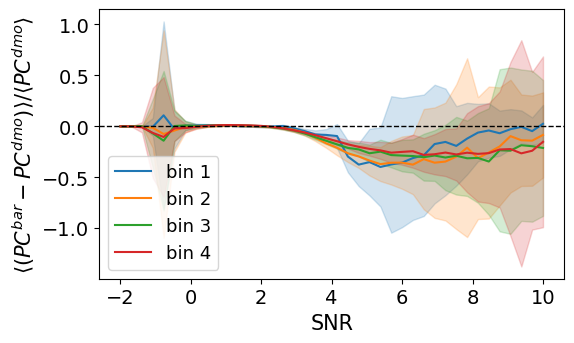

In [69]:
snr = np.linspace(-2, 10, fid_bar_bin1_pc.shape[2])

frac_diff1_pc = np.mean(fid_bar_bin1_pc[:,0,:] - fid_nobar_bin1_pc[:,0,:], axis=0) / (np.mean(fid_nobar_bin1_pc[:,0,:], axis=0) + 1)
std_fractional_diff_bin1_pc = np.std((fid_bar_bin1_pc[:,0,:] - fid_nobar_bin1_pc[:,0,:]) / (fid_nobar_bin1_pc[:,0,:]+ 1), axis=0)
frac_diff2_pc = np.mean(fid_bar_bin2_pc[:,0,:] - fid_nobar_bin2_pc[:,0,:], axis=0) / (np.mean(fid_nobar_bin2_pc[:,0,:], axis=0) + 1)
std_fractional_diff_bin2_pc = np.std((fid_bar_bin2_pc[:,0,:] - fid_nobar_bin2_pc[:,0,:]) / (fid_nobar_bin2_pc[:,0,:]+ 1), axis=0)
frac_diff3_pc = np.mean(fid_bar_bin3_pc[:,0,:] - fid_nobar_bin3_pc[:,0,:], axis=0) / (np.mean(fid_nobar_bin3_pc[:,0,:], axis=0) + 1)
std_fractional_diff_bin3_pc = np.std((fid_bar_bin3_pc[:,0,:] - fid_nobar_bin3_pc[:,0,:]) / (fid_nobar_bin3_pc[:,0,:]+ 1), axis=0)
frac_diff4_pc = np.mean(fid_bar_bin4_pc[:,0,:] - fid_nobar_bin4_pc[:,0,:], axis=0) / (np.mean(fid_nobar_bin4_pc[:,0,:], axis=0) + 1)
std_fractional_diff_bin4_pc = np.std((fid_bar_bin4_pc[:,0,:] - fid_nobar_bin4_pc[:,0,:]) / (fid_nobar_bin4_pc[:,0,:]+ 1), axis=0)

plt.figure(figsize=(6,3.5))

# change the size of the legend
plt.rcParams['legend.fontsize'] = 13
# change the size of the axes labels
plt.rcParams['axes.labelsize'] = 15
# change the size of the ticks
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.fill_between(snr, frac_diff1_pc-std_fractional_diff_bin1_pc, frac_diff1_pc+std_fractional_diff_bin1_pc, color='C0', alpha=0.2)
plt.fill_between(snr, frac_diff2_pc-std_fractional_diff_bin2_pc, frac_diff2_pc+std_fractional_diff_bin2_pc, color='C1', alpha=0.2)
plt.fill_between(snr, frac_diff3_pc-std_fractional_diff_bin3_pc, frac_diff3_pc+std_fractional_diff_bin3_pc, color='C2', alpha=0.2)
plt.fill_between(snr, frac_diff4_pc-std_fractional_diff_bin4_pc, frac_diff4_pc+std_fractional_diff_bin4_pc, color='C3', alpha=0.2)


plt.plot(snr, frac_diff1_pc, label='bin 1')
plt.plot(snr, frac_diff2_pc, label='bin 2')
plt.plot(snr, frac_diff3_pc, label='bin 3')
plt.plot(snr, frac_diff4_pc, label='bin 4')
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.legend()
plt.xlabel('SNR')
plt.ylabel(r'$\langle (PC^{bar} - PC^{dmo})\rangle / \langle PC^{dmo} \rangle$')

# save as transparent pdf
plt.savefig('/home/tersenov/software/bar_impact/plots/frac_diff_peaks_bins1234.pdf', bbox_inches='tight', transparent=True)

plt.show()


## l1

In [39]:
fid_bar_bin1_l1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_baryonified_bin1_noisy_s0.26_new_normalization.npy')
fid_nobar_bin1_l1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_nobaryons_bin1_noisy_s0.26_new_normalization.npy')

fid_bar_bin2_l1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_baryonified_bin2_noisy_s0.26_new_normalization.npy')
fid_nobar_bin2_l1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_nobaryons_bin2_noisy_s0.26_new_normalization.npy')

fid_bar_bin3_l1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_baryonified_bin3_noisy_s0.26_new_normalization.npy')
fid_nobar_bin3_l1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_nobaryons_bin3_noisy_s0.26_new_normalization.npy')

fid_bar_bin4_l1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_baryonified_bin4_noisy_s0.26_new_normalization.npy')
fid_nobar_bin4_l1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_nobaryons_bin4_noisy_s0.26_new_normalization.npy')

In [40]:
fid_bar_bin1_l1.shape, fid_nobar_bin1_l1.shape

((200, 5, 40), (200, 5, 40))

In [41]:
fid_bar_bin1_l1.shape

(200, 5, 40)

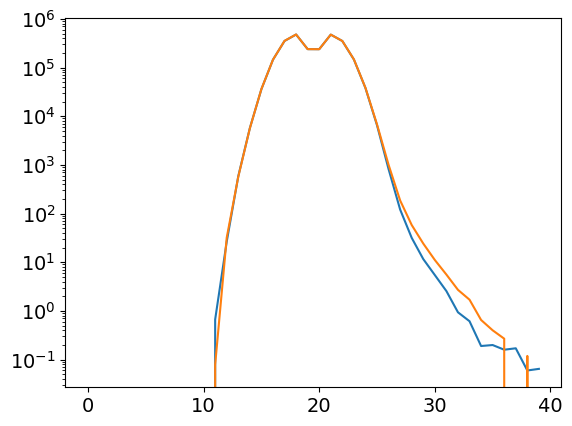

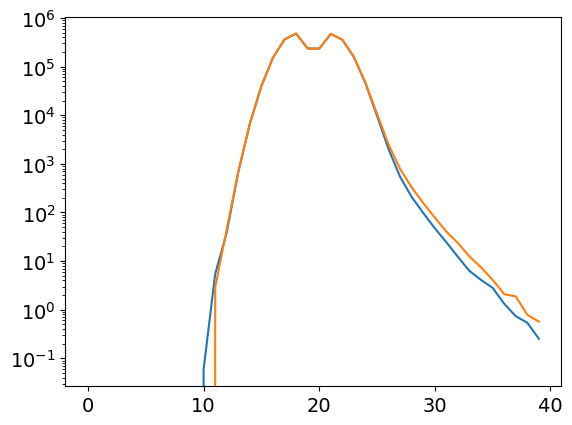

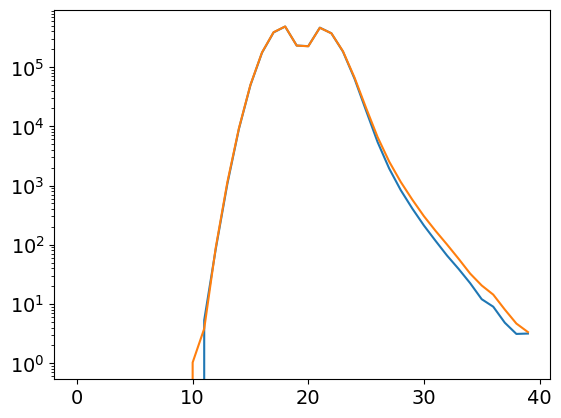

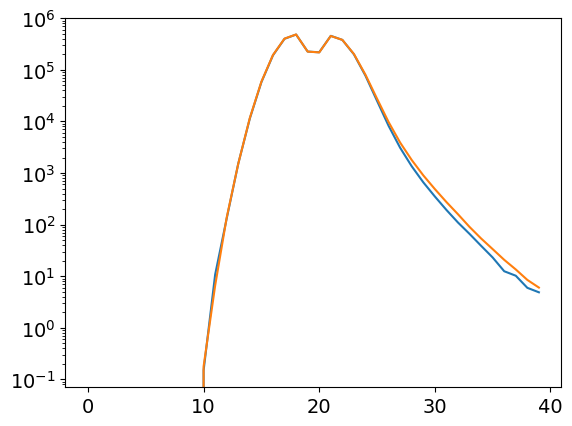

In [42]:
plt.plot(np.mean(fid_bar_bin1_l1[:,0,:], axis=0))
plt.plot(np.mean(fid_nobar_bin1_l1[:,0,:], axis=0))
plt.yscale('log')
plt.show()
plt.plot(np.mean(fid_bar_bin2_l1[:,0,:], axis=0))
plt.plot(np.mean(fid_nobar_bin2_l1[:,0,:], axis=0))
plt.yscale('log')
plt.show()
plt.plot(np.mean(fid_bar_bin3_l1[:,0,:], axis=0))
plt.plot(np.mean(fid_nobar_bin3_l1[:,0,:], axis=0))
plt.yscale('log')
plt.show()
plt.plot(np.mean(fid_bar_bin4_l1[:,0,:], axis=0))
plt.plot(np.mean(fid_nobar_bin4_l1[:,0,:], axis=0))
plt.yscale('log')
plt.show()

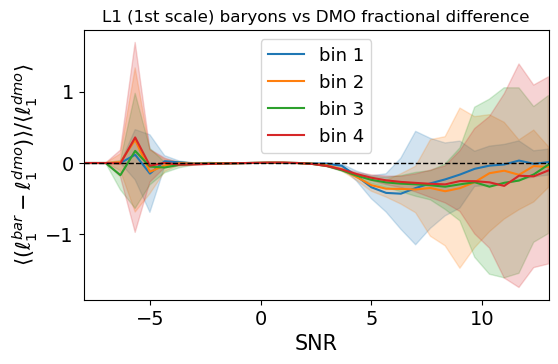

In [43]:
snr_l1 = np.linspace(-13, 13, fid_bar_bin1_l1.shape[2])

frac_diff1_l1 = np.mean(fid_bar_bin1_l1[:,0,:] - fid_nobar_bin1_l1[:,0,:], axis=0) / (np.mean(fid_nobar_bin1_l1[:,0,:], axis=0) + 5)
std_fractional_diff_bin1_l1 = np.std((fid_bar_bin1_l1[:,0,:] - fid_nobar_bin1_l1[:,0,:]) / (fid_nobar_bin1_l1[:,0,:]+ 5), axis=0)
frac_diff2_l1 = np.mean(fid_bar_bin2_l1[:,0,:] - fid_nobar_bin2_l1[:,0,:], axis=0) / (np.mean(fid_nobar_bin2_l1[:,0,:], axis=0) + 5)
std_fractional_diff_bin2_l1 = np.std((fid_bar_bin2_l1[:,0,:] - fid_nobar_bin2_l1[:,0,:]) / (fid_nobar_bin2_l1[:,0,:]+ 5), axis=0)
frac_diff3_l1 = np.mean(fid_bar_bin3_l1[:,0,:] - fid_nobar_bin3_l1[:,0,:], axis=0) / (np.mean(fid_nobar_bin3_l1[:,0,:], axis=0) + 5)
std_fractional_diff_bin3_l1 = np.std((fid_bar_bin3_l1[:,0,:] - fid_nobar_bin3_l1[:,0,:]) / (fid_nobar_bin3_l1[:,0,:]+ 5), axis=0)
frac_diff4_l1 = np.mean(fid_bar_bin4_l1[:,0,:] - fid_nobar_bin4_l1[:,0,:], axis=0) / (np.mean(fid_nobar_bin4_l1[:,0,:], axis=0) + 5)
std_fractional_diff_bin4_l1 = np.std((fid_bar_bin4_l1[:,0,:] - fid_nobar_bin4_l1[:,0,:]) / (fid_nobar_bin4_l1[:,0,:]+ 5), axis=0)

plt.figure(figsize=(6,3.5))

# change the size of the legend
plt.rcParams['legend.fontsize'] = 13
# change the size of the axes labels
plt.rcParams['axes.labelsize'] = 15
# change the size of the ticks
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.fill_between(snr_l1, frac_diff1_l1-std_fractional_diff_bin1_l1, frac_diff1_l1+std_fractional_diff_bin1_l1, color='C0', alpha=0.2)
plt.fill_between(snr_l1, frac_diff2_l1-std_fractional_diff_bin2_l1, frac_diff2_l1+std_fractional_diff_bin2_l1, color='C1', alpha=0.2)
plt.fill_between(snr_l1, frac_diff3_l1-std_fractional_diff_bin3_l1, frac_diff3_l1+std_fractional_diff_bin3_l1, color='C2', alpha=0.2)
plt.fill_between(snr_l1, frac_diff4_l1-std_fractional_diff_bin4_l1, frac_diff4_l1+std_fractional_diff_bin4_l1, color='C3', alpha=0.2)


plt.plot(snr_l1, frac_diff1_l1, label='bin 1')
plt.plot(snr_l1, frac_diff2_l1, label='bin 2')
plt.plot(snr_l1, frac_diff3_l1, label='bin 3')
plt.plot(snr_l1, frac_diff4_l1, label='bin 4')
plt.axhline(0, color='black', linestyle='--', lw=1)

plt.legend()
plt.xlim(-8, 13)
plt.xlabel('SNR')
plt.ylabel(r'$\langle (\ell_1^{bar} - \ell_1^{dmo})\rangle / \langle \ell_1^{dmo} \rangle$')
plt.title('L1 (1st scale) baryons vs DMO fractional difference')
# save as transparent pdf
plt.savefig('/home/tersenov/software/bar_impact/plots/frac_diff_L1_bins1234.pdf', bbox_inches='tight', transparent=True)

plt.show()


## BNT

In [11]:
fid_bar_bin1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_baryonified_bin1_noisy_s0.26.npy')
fid_nobar_bin1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_nobaryons_bin1_noisy_s0.26.npy')

fid_bar_bin2_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_baryonified_bin2_noisy_s0.26.npy')
fid_nobar_bin2_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_nobaryons_bin2_noisy_s0.26.npy')

fid_bar_bin3_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_baryonified_bin3_noisy_s0.26.npy')
fid_nobar_bin3_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_nobaryons_bin3_noisy_s0.26.npy')

fid_bar_bin4_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_baryonified_bin4_noisy_s0.26.npy')
fid_nobar_bin4_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_nobaryons_bin4_noisy_s0.26.npy')

In [12]:
# remove first element from each array (l=0)
fid_bar_bin1_bnt = fid_bar_bin1_bnt[:, 30:]
fid_nobar_bin1_bnt = fid_nobar_bin1_bnt[:, 30:]
fid_bar_bin2_bnt = fid_bar_bin2_bnt[:, 30:]
fid_nobar_bin2_bnt = fid_nobar_bin2_bnt[:, 30:]
fid_bar_bin3_bnt = fid_bar_bin3_bnt[:, 30:]
fid_nobar_bin3_bnt = fid_nobar_bin3_bnt[:, 30:]
fid_bar_bin4_bnt = fid_bar_bin4_bnt[:, 30:]
fid_nobar_bin4_bnt = fid_nobar_bin4_bnt[:, 30:]

new_size=10
fid_bar_bin1_bnt = rebin(fid_bar_bin1_bnt, new_size=new_size)
fid_nobar_bin1_bnt = rebin(fid_nobar_bin1_bnt, new_size=new_size)
fid_bar_bin2_bnt = rebin(fid_bar_bin2_bnt, new_size=new_size)
fid_nobar_bin2_bnt = rebin(fid_nobar_bin2_bnt, new_size=new_size)
fid_bar_bin3_bnt = rebin(fid_bar_bin3_bnt, new_size=new_size)
fid_nobar_bin3_bnt = rebin(fid_nobar_bin3_bnt, new_size=new_size)
fid_bar_bin4_bnt = rebin(fid_bar_bin4_bnt, new_size=new_size)
fid_nobar_bin4_bnt = rebin(fid_nobar_bin4_bnt, new_size=new_size)

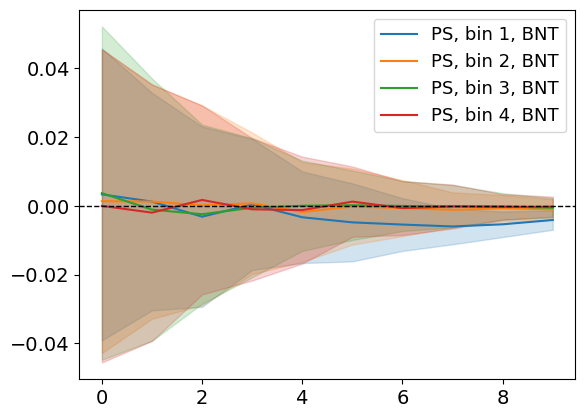

In [13]:
# plot fractional difference
frac_diff1_bnt = np.mean(fid_bar_bin1_bnt - fid_nobar_bin1_bnt, axis=0) / np.mean(fid_nobar_bin1_bnt, axis=0)
std_fractional_diff_bin1_bnt = np.std((fid_bar_bin1_bnt - fid_nobar_bin1_bnt) / fid_nobar_bin1_bnt, axis=0)
frac_diff2_bnt = np.mean(fid_bar_bin2_bnt - fid_nobar_bin2_bnt, axis=0) / np.mean(fid_nobar_bin2_bnt, axis=0)
std_fractional_diff_bin2_bnt = np.std((fid_bar_bin2_bnt - fid_nobar_bin2_bnt) / fid_nobar_bin2_bnt, axis=0)
frac_diff3_bnt = np.mean(fid_bar_bin3_bnt - fid_nobar_bin3_bnt, axis=0) / np.mean(fid_nobar_bin3_bnt, axis=0)
std_fractional_diff_bin3_bnt = np.std((fid_bar_bin3_bnt - fid_nobar_bin3_bnt) / fid_nobar_bin3_bnt, axis=0)
frac_diff4_bnt = np.mean(fid_bar_bin4_bnt - fid_nobar_bin4_bnt, axis=0) / np.mean(fid_nobar_bin4_bnt, axis=0)
std_fractional_diff_bin4_bnt = np.std((fid_bar_bin4_bnt - fid_nobar_bin4_bnt) / fid_nobar_bin4_bnt, axis=0)

# calculate the standard deviation of the fractional difference across the different realizations and plot as shaded region
plt.fill_between(np.arange(len(std_fractional_diff_bin1_bnt)), frac_diff1_bnt-std_fractional_diff_bin1_bnt, frac_diff1_bnt+std_fractional_diff_bin1_bnt, color='C0', alpha=0.2)
plt.fill_between(np.arange(len(std_fractional_diff_bin2_bnt)), frac_diff2_bnt-std_fractional_diff_bin2_bnt, frac_diff2_bnt+std_fractional_diff_bin2_bnt, color='C1', alpha=0.2)
plt.fill_between(np.arange(len(std_fractional_diff_bin3_bnt)), frac_diff3_bnt-std_fractional_diff_bin3_bnt, frac_diff3_bnt+std_fractional_diff_bin3_bnt, color='C2', alpha=0.2)
plt.fill_between(np.arange(len(std_fractional_diff_bin4_bnt)), frac_diff4_bnt-std_fractional_diff_bin4_bnt, frac_diff4_bnt+std_fractional_diff_bin4_bnt, color='C3', alpha=0.2)

plt.plot(frac_diff1_bnt, label='PS, bin 1, BNT')
plt.plot(frac_diff2_bnt, label='PS, bin 2, BNT')
plt.plot(frac_diff3_bnt, label='PS, bin 3, BNT')
plt.plot(frac_diff4_bnt, label='PS, bin 4, BNT')

plt.axhline(0, color='black', linestyle='--', lw=1)
plt.legend()
# plt.ylim(-0.1, 0.1)
plt.show()

## BNT Peaks

In [93]:
fid_bar_bin1_pc_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_peak_counts_fiducial_baryonified_bin1_noisy_s0.26_new_normalization.npy')
fid_nobar_bin1_pc_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_peak_counts_fiducial_nobaryons_bin1_noisy_s0.26_new_normalization.npy')

fid_bar_bin2_pc_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_peak_counts_fiducial_baryonified_bin2_noisy_s0.26_new_normalization.npy')
fid_nobar_bin2_pc_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_peak_counts_fiducial_nobaryons_bin2_noisy_s0.26_new_normalization.npy')

fid_bar_bin3_pc_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_peak_counts_fiducial_baryonified_bin3_noisy_s0.26_new_normalization.npy')
fid_nobar_bin3_pc_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_peak_counts_fiducial_nobaryons_bin3_noisy_s0.26_new_normalization.npy')

fid_bar_bin4_pc_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_peak_counts_fiducial_baryonified_bin4_noisy_s0.26_new_normalization.npy')
fid_nobar_bin4_pc_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_peak_counts_fiducial_nobaryons_bin4_noisy_s0.26_new_normalization.npy')

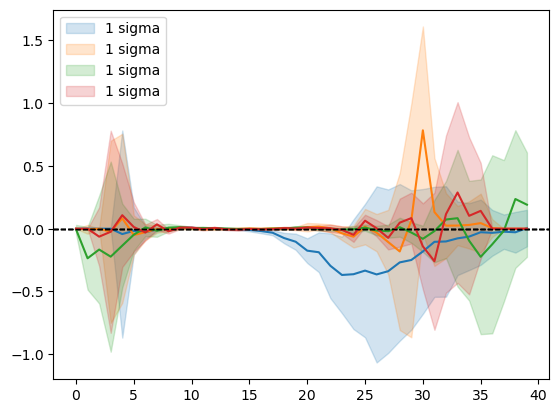

In [94]:
frac_diff1_pc_bnt = np.mean(fid_bar_bin1_pc_bnt[:,0,:] - fid_nobar_bin1_pc_bnt[:,0,:], axis=0) / (np.mean(fid_nobar_bin1_pc_bnt[:,0,:], axis=0) + 1)
plt.plot(frac_diff1_pc_bnt)
std_fractional_diff_bin1_pc_bnt = np.std((fid_bar_bin1_pc_bnt[:,0,:] - fid_nobar_bin1_pc_bnt[:,0,:]) / (fid_nobar_bin1_pc_bnt[:,0,:]+ 1), axis=0)
plt.fill_between(np.arange(len(std_fractional_diff_bin1_pc_bnt)), frac_diff1_pc_bnt-std_fractional_diff_bin1_pc_bnt, frac_diff1_pc_bnt+std_fractional_diff_bin1_pc_bnt, color='C0', alpha=0.2, label='1 sigma')
plt.axhline(0, color='black', linestyle='--', lw=1)

frac_diff2_pc_bnt = np.mean(fid_bar_bin2_pc_bnt[:,0,:] - fid_nobar_bin2_pc_bnt[:,0,:], axis=0) / (np.mean(fid_nobar_bin2_pc_bnt[:,0,:], axis=0) + 1)
plt.plot(frac_diff2_pc_bnt)
std_fractional_diff_bin2_pc_bnt = np.std((fid_bar_bin2_pc_bnt[:,0,:] - fid_nobar_bin2_pc_bnt[:,0,:]) / (fid_nobar_bin2_pc_bnt[:,0,:]+ 1), axis=0)
plt.fill_between(np.arange(len(std_fractional_diff_bin2_pc_bnt)), frac_diff2_pc_bnt-std_fractional_diff_bin2_pc_bnt, frac_diff2_pc_bnt+std_fractional_diff_bin2_pc_bnt, color='C1', alpha=0.2, label='1 sigma')
plt.axhline(0, color='black', linestyle='--', lw=1)

frac_diff3_pc_bnt = np.mean(fid_bar_bin3_pc_bnt[:,0,:] - fid_nobar_bin3_pc_bnt[:,0,:], axis=0) / (np.mean(fid_nobar_bin3_pc_bnt[:,0,:], axis=0) + 1)
plt.plot(frac_diff3_pc_bnt)
std_fractional_diff_bin3_pc_bnt = np.std((fid_bar_bin3_pc_bnt[:,0,:] - fid_nobar_bin3_pc_bnt[:,0,:]) / (fid_nobar_bin3_pc_bnt[:,0,:]+ 1), axis=0)
plt.fill_between(np.arange(len(std_fractional_diff_bin3_pc_bnt)), frac_diff3_pc_bnt-std_fractional_diff_bin3_pc_bnt, frac_diff3_pc_bnt+std_fractional_diff_bin3_pc_bnt, color='C2', alpha=0.2, label='1 sigma')
plt.axhline(0, color='black', linestyle='--', lw=1)

frac_diff4_pc_bnt = np.mean(fid_bar_bin4_pc_bnt[:,0,:] - fid_nobar_bin4_pc_bnt[:,0,:], axis=0) / (np.mean(fid_nobar_bin4_pc_bnt[:,0,:], axis=0) + 1)
plt.plot(frac_diff4_pc_bnt)
std_fractional_diff_bin4_pc_bnt = np.std((fid_bar_bin4_pc_bnt[:,0,:] - fid_nobar_bin4_pc_bnt[:,0,:]) / (fid_nobar_bin4_pc_bnt[:,0,:]+ 1), axis=0)
plt.fill_between(np.arange(len(std_fractional_diff_bin4_pc_bnt)), frac_diff4_pc_bnt-std_fractional_diff_bin4_pc_bnt, frac_diff4_pc_bnt+std_fractional_diff_bin4_pc_bnt, color='C3', alpha=0.2, label='1 sigma')
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.legend()
plt.show()

## BNT l1

In [32]:
fid_bar_bin1_l1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_baryonified_bin1_noisy_s0.26_new_normalization.npy')
fid_nobar_bin1_l1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_nobaryons_bin1_noisy_s0.26_new_normalization.npy')

fid_bar_bin2_l1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_baryonified_bin2_noisy_s0.26_new_normalization.npy')
fid_nobar_bin2_l1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_nobaryons_bin2_noisy_s0.26_new_normalization.npy')

fid_bar_bin3_l1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_baryonified_bin3_noisy_s0.26_new_normalization.npy')
fid_nobar_bin3_l1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_nobaryons_bin3_noisy_s0.26_new_normalization.npy')

fid_bar_bin4_l1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_baryonified_bin4_noisy_s0.26_new_normalization.npy')
fid_nobar_bin4_l1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_nobaryons_bin4_noisy_s0.26_new_normalization.npy')

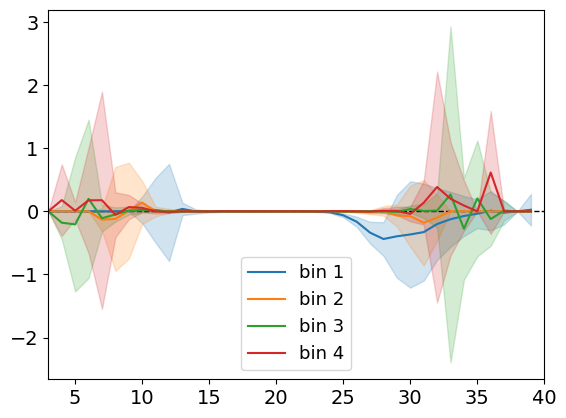

In [33]:
frac_diff1_l1_bnt = np.mean(fid_bar_bin1_l1_bnt[:,0,:] - fid_nobar_bin1_l1_bnt[:,0,:], axis=0) / (np.mean(fid_nobar_bin1_l1_bnt[:,0,:], axis=0) + 5)
std_fractional_diff_bin1_l1_bnt = np.std((fid_bar_bin1_l1_bnt[:,0,:] - fid_nobar_bin1_l1_bnt[:,0,:]) / (fid_nobar_bin1_l1_bnt[:,0,:]+ 5), axis=0)
frac_diff2_l1_bnt = np.mean(fid_bar_bin2_l1_bnt[:,0,:] - fid_nobar_bin2_l1_bnt[:,0,:], axis=0) / (np.mean(fid_nobar_bin2_l1_bnt[:,0,:], axis=0) + 5)
std_fractional_diff_bin2_l1_bnt = np.std((fid_bar_bin2_l1_bnt[:,0,:] - fid_nobar_bin2_l1_bnt[:,0,:]) / (fid_nobar_bin2_l1_bnt[:,0,:]+ 5), axis=0)
frac_diff3_l1_bnt = np.mean(fid_bar_bin3_l1_bnt[:,0,:] - fid_nobar_bin3_l1_bnt[:,0,:], axis=0) / (np.mean(fid_nobar_bin3_l1_bnt[:,0,:], axis=0) + 5)
std_fractional_diff_bin3_l1_bnt = np.std((fid_bar_bin3_l1_bnt[:,0,:] - fid_nobar_bin3_l1_bnt[:,0,:]) / (fid_nobar_bin3_l1_bnt[:,0,:]+ 5), axis=0)
frac_diff4_l1_bnt = np.mean(fid_bar_bin4_l1_bnt[:,0,:] - fid_nobar_bin4_l1_bnt[:,0,:], axis=0) / (np.mean(fid_nobar_bin4_l1_bnt[:,0,:], axis=0) + 5)
std_fractional_diff_bin4_l1_bnt = np.std((fid_bar_bin4_l1_bnt[:,0,:] - fid_nobar_bin4_l1_bnt[:,0,:]) / (fid_nobar_bin4_l1_bnt[:,0,:]+ 5), axis=0)


plt.fill_between(np.arange(len(std_fractional_diff_bin1_l1_bnt)), frac_diff1_l1_bnt-std_fractional_diff_bin1_l1_bnt, frac_diff1_l1_bnt+std_fractional_diff_bin1_l1_bnt, color='C0', alpha=0.2)
plt.fill_between(np.arange(len(std_fractional_diff_bin2_l1_bnt)), frac_diff2_l1_bnt-std_fractional_diff_bin2_l1_bnt, frac_diff2_l1_bnt+std_fractional_diff_bin2_l1_bnt, color='C1', alpha=0.2)
plt.fill_between(np.arange(len(std_fractional_diff_bin3_l1_bnt)), frac_diff3_l1_bnt-std_fractional_diff_bin3_l1_bnt, frac_diff3_l1_bnt+std_fractional_diff_bin3_l1_bnt, color='C2', alpha=0.2)
plt.fill_between(np.arange(len(std_fractional_diff_bin4_l1_bnt)), frac_diff4_l1_bnt-std_fractional_diff_bin4_l1_bnt, frac_diff4_l1_bnt+std_fractional_diff_bin4_l1_bnt, color='C3', alpha=0.2)

plt.axhline(0, color='black', linestyle='--', lw=1)

plt.plot(frac_diff1_l1_bnt, label='bin 1')
plt.plot(frac_diff2_l1_bnt, label='bin 2')
plt.plot(frac_diff3_l1_bnt, label='bin 3')
plt.plot(frac_diff4_l1_bnt, label='bin 4')

plt.legend()
plt.xlim(3, 40)
plt.show()

In [35]:
frac_diff1_l1_bnt.shape

(40,)

In [ ]:
# snr_l1 = np.linspace(-13, 13, frac_diff1_l1_bnt.shape[0])

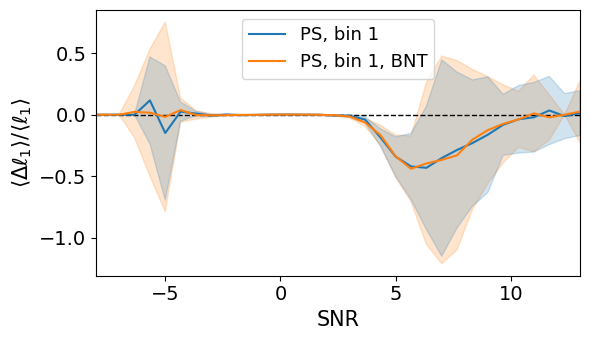

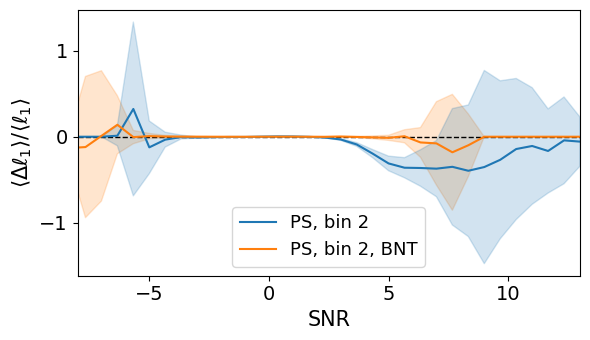

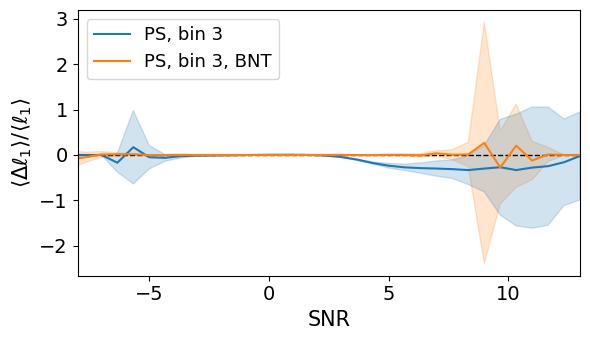

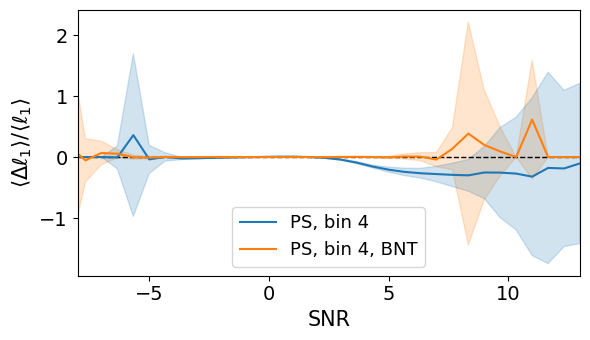

In [50]:
# change the size of the legend
plt.rcParams['legend.fontsize'] = 13
# change the size of the axes labels
plt.rcParams['axes.labelsize'] = 15
# change the size of the ticks
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.figure(figsize=(6,3.5))
plt.fill_between(snr_l1, frac_diff1_l1_bnt-std_fractional_diff_bin1_l1_bnt, frac_diff1_l1_bnt+std_fractional_diff_bin1_l1_bnt, color='C1', alpha=0.2)
plt.fill_between(snr_l1, frac_diff1_l1-std_fractional_diff_bin1_l1, frac_diff1_l1+std_fractional_diff_bin1_l1, color='C0', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(snr_l1, frac_diff1_l1, label='PS, bin 1', color='C0')
plt.plot(snr_l1, frac_diff1_l1_bnt, label='PS, bin 1, BNT', color='C1')
plt.xlabel(r'SNR')
plt.ylabel(r'$\langle \Delta \ell_1 \rangle / \langle \ell_1 \rangle$')
plt.legend()
plt.xlim(-8, 13)
plt.tight_layout()
# save as svg
plt.savefig('/home/tersenov/software/bar_impact/plots/l1_fractional_difference_bin1_bnt_vs_no_bnt.svg', format='svg')
plt.show()

plt.figure(figsize=(6,3.5))
plt.fill_between(snr_l1, frac_diff2_l1_bnt-std_fractional_diff_bin2_l1_bnt, frac_diff2_l1_bnt+std_fractional_diff_bin2_l1_bnt, color='C1', alpha=0.2)
plt.fill_between(snr_l1, frac_diff2_l1-std_fractional_diff_bin2_l1, frac_diff2_l1+std_fractional_diff_bin2_l1, color='C0', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(snr_l1, frac_diff2_l1, label='PS, bin 2', color='C0')
plt.plot(snr_l1, frac_diff2_l1_bnt, label='PS, bin 2, BNT', color='C1')
plt.xlabel(r'SNR')
plt.ylabel(r'$\langle \Delta \ell_1 \rangle / \langle \ell_1 \rangle$')
plt.legend()
plt.xlim(-8, 13)
plt.tight_layout()
# save as svg
plt.savefig('/home/tersenov/software/bar_impact/plots/l1_fractional_difference_bin2_bnt_vs_no_bnt.svg', format='svg')
plt.show()

plt.figure(figsize=(6,3.5))
plt.fill_between(snr_l1, frac_diff3_l1_bnt-std_fractional_diff_bin3_l1_bnt, frac_diff3_l1_bnt+std_fractional_diff_bin3_l1_bnt, color='C1', alpha=0.2)
plt.fill_between(snr_l1, frac_diff3_l1-std_fractional_diff_bin3_l1, frac_diff3_l1+std_fractional_diff_bin3_l1, color='C0', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(snr_l1, frac_diff3_l1, label='PS, bin 3', color='C0')
plt.plot(snr_l1, frac_diff3_l1_bnt, label='PS, bin 3, BNT', color='C1')
plt.xlabel(r'SNR')
plt.ylabel(r'$\langle \Delta \ell_1 \rangle / \langle \ell_1 \rangle$')
plt.legend()
plt.xlim(-8, 13)
plt.tight_layout()
# save as svg
plt.savefig('/home/tersenov/software/bar_impact/plots/l1_fractional_difference_bin3_bnt_vs_no_bnt.svg', format='svg')
plt.show()  

plt.figure(figsize=(6,3.5))
plt.fill_between(snr_l1, frac_diff4_l1_bnt-std_fractional_diff_bin4_l1_bnt, frac_diff4_l1_bnt+std_fractional_diff_bin4_l1_bnt, color='C1', alpha=0.2)
plt.fill_between(snr_l1, frac_diff4_l1-std_fractional_diff_bin4_l1, frac_diff4_l1+std_fractional_diff_bin4_l1, color='C0', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(snr_l1, frac_diff4_l1, label='PS, bin 4', color='C0')
plt.plot(snr_l1, frac_diff4_l1_bnt, label='PS, bin 4, BNT', color='C1')
plt.xlabel(r'SNR')
plt.ylabel(r'$\langle \Delta \ell_1 \rangle / \langle \ell_1 \rangle$')
plt.legend()
plt.xlim(-8, 13)
plt.tight_layout()
# save as svg
plt.savefig('/home/tersenov/software/bar_impact/plots/l1_fractional_difference_bin4_bnt_vs_no_bnt.svg', format='svg')
plt.show()

## BNT vs noBNT stats

### Power Spectrum

In [3]:
fid_bar_bin1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_baryonified_bin1_noisy_s0.26.npy')
fid_nobar_bin1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_nobaryons_bin1_noisy_s0.26.npy')
fid_bar_bin2 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_baryonified_bin2_noisy_s0.26.npy')
fid_nobar_bin2 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_nobaryons_bin2_noisy_s0.26.npy')
fid_bar_bin3 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_baryonified_bin3_noisy_s0.26.npy')
fid_nobar_bin3 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_nobaryons_bin3_noisy_s0.26.npy')
fid_bar_bin4 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_baryonified_bin4_noisy_s0.26.npy')
fid_nobar_bin4 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_nobaryons_bin4_noisy_s0.26.npy')
fid_bar_bin1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_baryonified_bin1_noisy_s0.26.npy')
fid_nobar_bin1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_nobaryons_bin1_noisy_s0.26.npy')
fid_bar_bin2_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_baryonified_bin2_noisy_s0.26.npy')
fid_nobar_bin2_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_nobaryons_bin2_noisy_s0.26.npy')
fid_bar_bin3_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_baryonified_bin3_noisy_s0.26.npy')
fid_nobar_bin3_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_nobaryons_bin3_noisy_s0.26.npy')
fid_bar_bin4_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_baryonified_bin4_noisy_s0.26.npy')
fid_nobar_bin4_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_nobaryons_bin4_noisy_s0.26.npy')

In [7]:
fid_bar_bin1 = fid_bar_bin1[:, 30:]
fid_nobar_bin1 = fid_nobar_bin1[:, 30:]
fid_bar_bin1_bnt = fid_bar_bin1_bnt[:, 30:]
fid_nobar_bin1_bnt = fid_nobar_bin1_bnt[:, 30:]
fid_bar_bin2 = fid_bar_bin2[:, 30:]
fid_nobar_bin2 = fid_nobar_bin2[:, 30:]
fid_bar_bin2_bnt = fid_bar_bin2_bnt[:, 30:]
fid_nobar_bin2_bnt = fid_nobar_bin2_bnt[:, 30:]
fid_bar_bin3 = fid_bar_bin3[:, 30:]
fid_nobar_bin3 = fid_nobar_bin3[:, 30:]
fid_bar_bin3_bnt = fid_bar_bin3_bnt[:, 30:]
fid_nobar_bin3_bnt = fid_nobar_bin3_bnt[:, 30:]
fid_bar_bin4 = fid_bar_bin4[:, 30:]
fid_nobar_bin4 = fid_nobar_bin4[:, 30:]
fid_bar_bin4_bnt = fid_bar_bin4_bnt[:, 30:]
fid_nobar_bin4_bnt = fid_nobar_bin4_bnt[:, 30:]

new_size=10
fid_bar_bin1 = rebin(fid_bar_bin1, new_size=new_size)
fid_nobar_bin1 = rebin(fid_nobar_bin1, new_size=new_size)
fid_bar_bin1_bnt = rebin(fid_bar_bin1_bnt, new_size=new_size)
fid_nobar_bin1_bnt = rebin(fid_nobar_bin1_bnt, new_size=new_size)
fid_bar_bin2 = rebin(fid_bar_bin2, new_size=new_size)
fid_nobar_bin2 = rebin(fid_nobar_bin2, new_size=new_size)
fid_bar_bin2_bnt = rebin(fid_bar_bin2_bnt, new_size=new_size)
fid_nobar_bin2_bnt = rebin(fid_nobar_bin2_bnt, new_size=new_size)
fid_bar_bin3 = rebin(fid_bar_bin3, new_size=new_size)
fid_nobar_bin3 = rebin(fid_nobar_bin3, new_size=new_size)
fid_bar_bin3_bnt = rebin(fid_bar_bin3_bnt, new_size=new_size)
fid_nobar_bin3_bnt = rebin(fid_nobar_bin3_bnt, new_size=new_size)
fid_bar_bin4 = rebin(fid_bar_bin4, new_size=new_size)
fid_nobar_bin4 = rebin(fid_nobar_bin4, new_size=new_size)
fid_bar_bin4_bnt = rebin(fid_bar_bin4_bnt, new_size=new_size)
fid_nobar_bin4_bnt = rebin(fid_nobar_bin4_bnt, new_size=new_size)

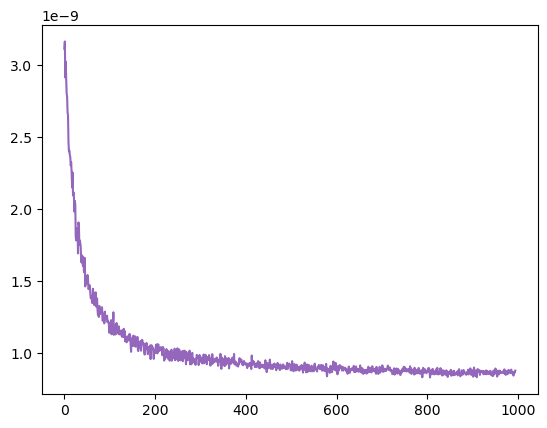

In [5]:
plt.plot(np.mean(fid_bar_bin1, axis=0), label='l1, bin 1, bar', color='C4')

In [17]:
fid_bar_bin1.shape

(200, 10)

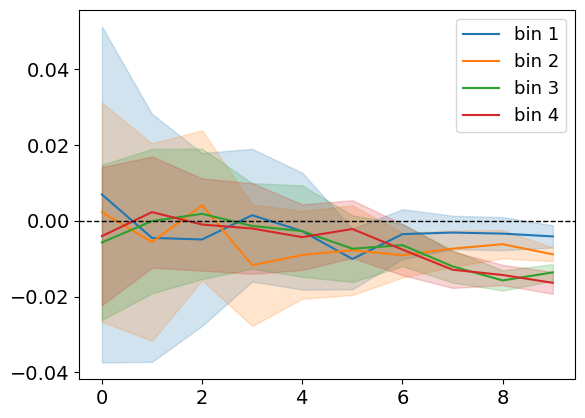

In [18]:
# plot fractional difference
frac_diff1 = np.mean(fid_bar_bin1 - fid_nobar_bin1, axis=0) / np.mean(fid_nobar_bin1, axis=0)
std_fractional_diff_bin1 = np.std((fid_bar_bin1 - fid_nobar_bin1) / fid_nobar_bin1, axis=0)
frac_diff2 = np.mean(fid_bar_bin2 - fid_nobar_bin2, axis=0) / np.mean(fid_nobar_bin2, axis=0)
std_fractional_diff_bin2 = np.std((fid_bar_bin2 - fid_nobar_bin2) / fid_nobar_bin2, axis=0)
frac_diff3 = np.mean(fid_bar_bin3 - fid_nobar_bin3, axis=0) / np.mean(fid_nobar_bin3, axis=0)
std_fractional_diff_bin3 = np.std((fid_bar_bin3 - fid_nobar_bin3) / fid_nobar_bin3, axis=0)
frac_diff4 = np.mean(fid_bar_bin4 - fid_nobar_bin4, axis=0) / np.mean(fid_nobar_bin4, axis=0)
std_fractional_diff_bin4 = np.std((fid_bar_bin4 - fid_nobar_bin4) / fid_nobar_bin4, axis=0)

plt.figure()
# calculate the standard deviation of the fractional difference across the different realizations and plot as shaded region
plt.fill_between(np.arange(len(std_fractional_diff_bin1)), frac_diff1-std_fractional_diff_bin1, frac_diff1+std_fractional_diff_bin1, color='C0', alpha=0.2)
plt.fill_between(np.arange(len(std_fractional_diff_bin2)), frac_diff2-std_fractional_diff_bin2, frac_diff2+std_fractional_diff_bin2, color='C1', alpha=0.2)
plt.fill_between(np.arange(len(std_fractional_diff_bin3)), frac_diff3-std_fractional_diff_bin3, frac_diff3+std_fractional_diff_bin3, color='C2', alpha=0.2)
plt.fill_between(np.arange(len(std_fractional_diff_bin4)), frac_diff4-std_fractional_diff_bin4, frac_diff4+std_fractional_diff_bin4, color='C3', alpha=0.2)

plt.plot(frac_diff1, label='bin 1')
plt.plot(frac_diff2, label='bin 2')
plt.plot(frac_diff3, label='bin 3')
plt.plot(frac_diff4, label='bin 4')

plt.axhline(0, color='black', linestyle='--', lw=1)
plt.legend()
# plt.ylim(-0.1, 0.1)
plt.show()

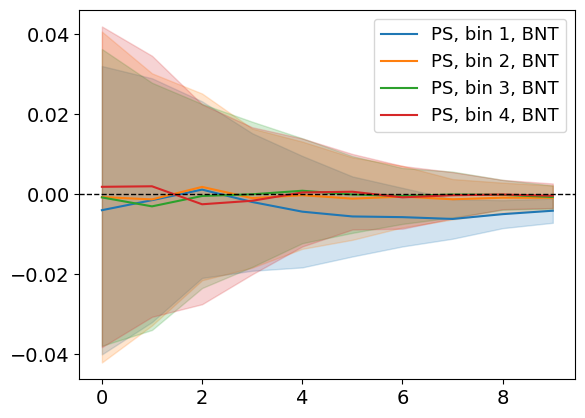

In [12]:
# plot fractional difference
frac_diff1_bnt = np.mean(fid_bar_bin1_bnt - fid_nobar_bin1_bnt, axis=0) / np.mean(fid_nobar_bin1_bnt, axis=0)
std_fractional_diff_bin1_bnt = np.std((fid_bar_bin1_bnt - fid_nobar_bin1_bnt) / fid_nobar_bin1_bnt, axis=0)
frac_diff2_bnt = np.mean(fid_bar_bin2_bnt - fid_nobar_bin2_bnt, axis=0) / np.mean(fid_nobar_bin2_bnt, axis=0)
std_fractional_diff_bin2_bnt = np.std((fid_bar_bin2_bnt - fid_nobar_bin2_bnt) / fid_nobar_bin2_bnt, axis=0)
frac_diff3_bnt = np.mean(fid_bar_bin3_bnt - fid_nobar_bin3_bnt, axis=0) / np.mean(fid_nobar_bin3_bnt, axis=0)
std_fractional_diff_bin3_bnt = np.std((fid_bar_bin3_bnt - fid_nobar_bin3_bnt) / fid_nobar_bin3_bnt, axis=0)
frac_diff4_bnt = np.mean(fid_bar_bin4_bnt - fid_nobar_bin4_bnt, axis=0) / np.mean(fid_nobar_bin4_bnt, axis=0)
std_fractional_diff_bin4_bnt = np.std((fid_bar_bin4_bnt - fid_nobar_bin4_bnt) / fid_nobar_bin4_bnt, axis=0)

# calculate the standard deviation of the fractional difference across the different realizations and plot as shaded region
plt.fill_between(np.arange(len(std_fractional_diff_bin1_bnt)), frac_diff1_bnt-std_fractional_diff_bin1_bnt, frac_diff1_bnt+std_fractional_diff_bin1_bnt, color='C0', alpha=0.2)
plt.fill_between(np.arange(len(std_fractional_diff_bin2_bnt)), frac_diff2_bnt-std_fractional_diff_bin2_bnt, frac_diff2_bnt+std_fractional_diff_bin2_bnt, color='C1', alpha=0.2)
plt.fill_between(np.arange(len(std_fractional_diff_bin3_bnt)), frac_diff3_bnt-std_fractional_diff_bin3_bnt, frac_diff3_bnt+std_fractional_diff_bin3_bnt, color='C2', alpha=0.2)
plt.fill_between(np.arange(len(std_fractional_diff_bin4_bnt)), frac_diff4_bnt-std_fractional_diff_bin4_bnt, frac_diff4_bnt+std_fractional_diff_bin4_bnt, color='C3', alpha=0.2)

plt.plot(frac_diff1_bnt, label='PS, bin 1, BNT')
plt.plot(frac_diff2_bnt, label='PS, bin 2, BNT')
plt.plot(frac_diff3_bnt, label='PS, bin 3, BNT')
plt.plot(frac_diff4_bnt, label='PS, bin 4, BNT')

plt.axhline(0, color='black', linestyle='--', lw=1)
plt.legend()
# plt.ylim(-0.1, 0.1)
plt.show()

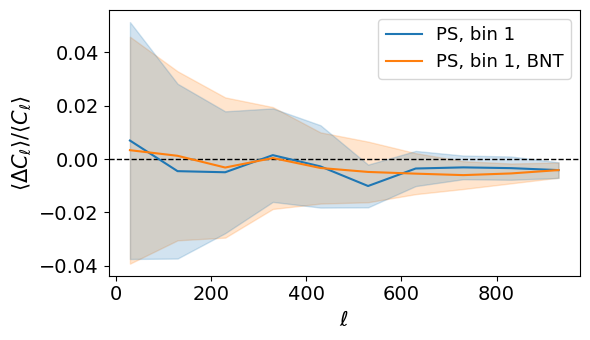

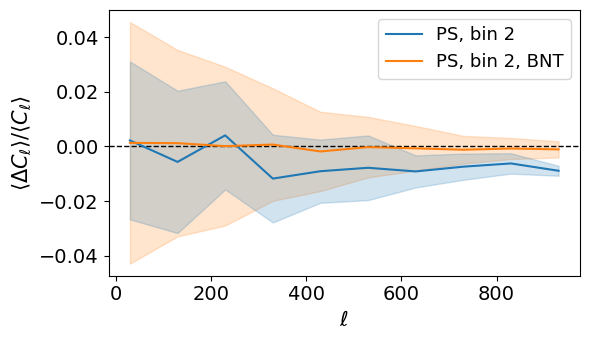

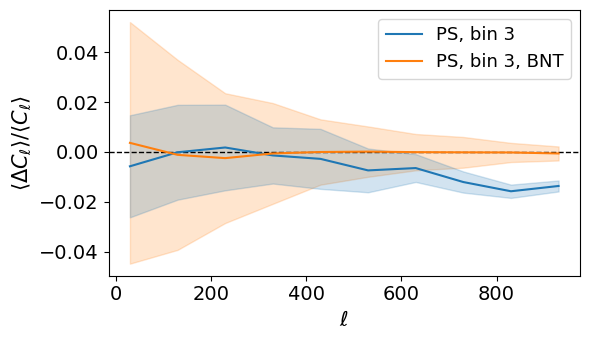

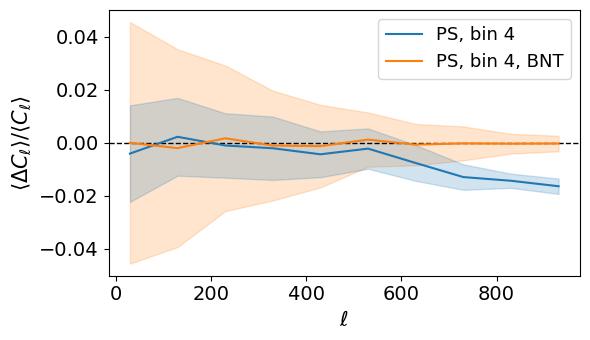

In [28]:
# change the size of the legend
plt.rcParams['legend.fontsize'] = 13
# change the size of the axes labels
plt.rcParams['axes.labelsize'] = 15
# change the size of the ticks
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.figure(figsize=(6,3.5))
plt.fill_between(ells_rebinned, frac_diff1_bnt-std_fractional_diff_bin1_bnt, frac_diff1_bnt+std_fractional_diff_bin1_bnt, color='C1', alpha=0.2)
plt.fill_between(ells_rebinned, frac_diff1-std_fractional_diff_bin1, frac_diff1+std_fractional_diff_bin1, color='C0', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(ells_rebinned, frac_diff1, label='PS, bin 1', color='C0')
plt.plot(ells_rebinned, frac_diff1_bnt, label='PS, bin 1, BNT', color='C1')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\langle \Delta C_\ell \rangle / \langle C_\ell \rangle$')
plt.legend()
plt.tight_layout()
# save as svg
plt.savefig('/home/tersenov/software/bar_impact/plots/Cl_fractional_difference_bin1_bnt_vs_no_bnt.svg', format='svg')
plt.show()

plt.figure(figsize=(6,3.5))
plt.fill_between(ells_rebinned, frac_diff2_bnt-std_fractional_diff_bin2_bnt, frac_diff2_bnt+std_fractional_diff_bin2_bnt, color='C1', alpha=0.2)
plt.fill_between(ells_rebinned, frac_diff2-std_fractional_diff_bin2, frac_diff2+std_fractional_diff_bin2, color='C0', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(ells_rebinned, frac_diff2, label='PS, bin 2', color='C0')
plt.plot(ells_rebinned, frac_diff2_bnt, label='PS, bin 2, BNT', color='C1')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\langle \Delta C_\ell \rangle / \langle C_\ell \rangle$')
plt.legend()
plt.tight_layout()
# save as svg
plt.savefig('/home/tersenov/software/bar_impact/plots/Cl_fractional_difference_bin2_bnt_vs_no_bnt.svg', format='svg')
plt.show()

plt.figure(figsize=(6,3.5))
plt.fill_between(ells_rebinned, frac_diff3_bnt-std_fractional_diff_bin3_bnt, frac_diff3_bnt+std_fractional_diff_bin3_bnt, color='C1', alpha=0.2)
plt.fill_between(ells_rebinned, frac_diff3-std_fractional_diff_bin3, frac_diff3+std_fractional_diff_bin3, color='C0', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(ells_rebinned, frac_diff3, label='PS, bin 3', color='C0')
plt.plot(ells_rebinned, frac_diff3_bnt, label='PS, bin 3, BNT', color='C1')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\langle \Delta C_\ell \rangle / \langle C_\ell \rangle$')
plt.legend()
plt.tight_layout()
plt.savefig('/home/tersenov/software/bar_impact/plots/Cl_fractional_difference_bin3_bnt_vs_no_bnt.svg', format='svg')
plt.show()

plt.figure(figsize=(6,3.5))
plt.fill_between(ells_rebinned, frac_diff4_bnt-std_fractional_diff_bin4_bnt, frac_diff4_bnt+std_fractional_diff_bin4_bnt, color='C1', alpha=0.2)
plt.fill_between(ells_rebinned, frac_diff4-std_fractional_diff_bin4, frac_diff4+std_fractional_diff_bin4, color='C0', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(ells_rebinned, frac_diff4, label='PS, bin 4', color='C0')
plt.plot(ells_rebinned, frac_diff4_bnt, label='PS, bin 4, BNT', color='C1')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\langle \Delta C_\ell \rangle / \langle C_\ell \rangle$')
plt.legend()
plt.tight_layout()
plt.savefig('/home/tersenov/software/bar_impact/plots/Cl_fractional_difference_bin4_bnt_vs_no_bnt.svg', format='svg')
plt.show()

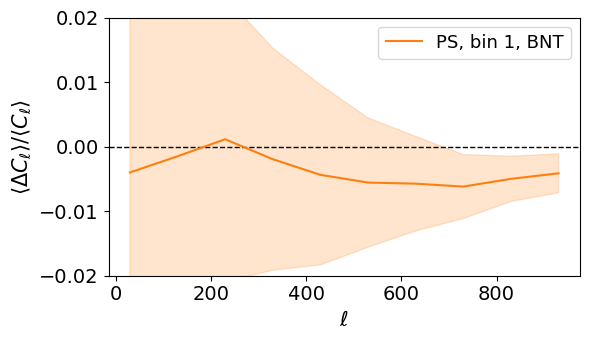

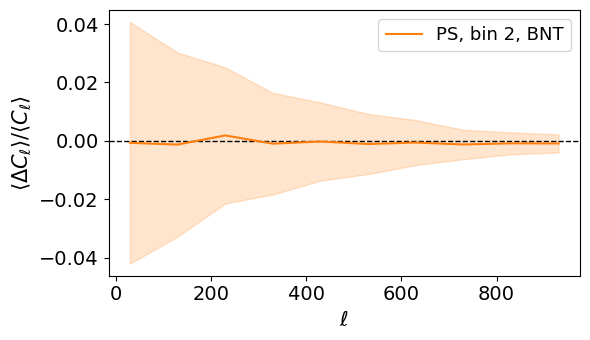

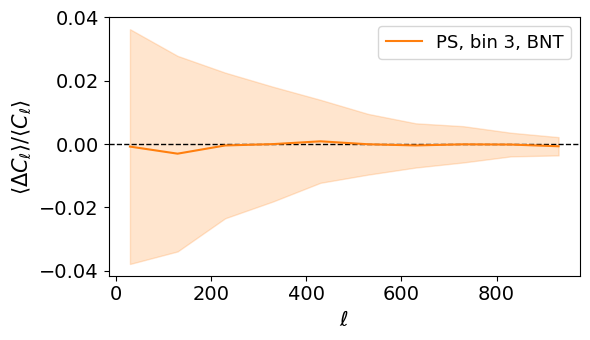

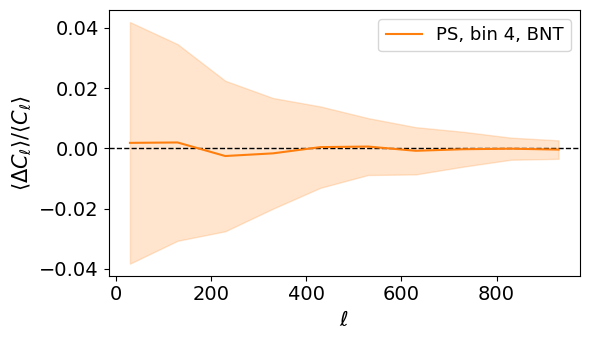

In [17]:
# change the size of the legend
plt.rcParams['legend.fontsize'] = 13
# change the size of the axes labels
plt.rcParams['axes.labelsize'] = 15
# change the size of the ticks
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.figure(figsize=(6,3.5))
plt.fill_between(ells_rebinned, frac_diff1_bnt-std_fractional_diff_bin1_bnt, frac_diff1_bnt+std_fractional_diff_bin1_bnt, color='C1', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(ells_rebinned, frac_diff1_bnt, label='PS, bin 1, BNT', color='C1')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\langle \Delta C_\ell \rangle / \langle C_\ell \rangle$')
plt.legend()
plt.ylim(-0.02, 0.02)
plt.tight_layout()
# save as svg
plt.show()

plt.figure(figsize=(6,3.5))
plt.fill_between(ells_rebinned, frac_diff2_bnt-std_fractional_diff_bin2_bnt, frac_diff2_bnt+std_fractional_diff_bin2_bnt, color='C1', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(ells_rebinned, frac_diff2_bnt, label='PS, bin 2, BNT', color='C1')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\langle \Delta C_\ell \rangle / \langle C_\ell \rangle$')
plt.legend()
plt.tight_layout()
# save as svg
plt.show()

plt.figure(figsize=(6,3.5))
plt.fill_between(ells_rebinned, frac_diff3_bnt-std_fractional_diff_bin3_bnt, frac_diff3_bnt+std_fractional_diff_bin3_bnt, color='C1', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(ells_rebinned, frac_diff3_bnt, label='PS, bin 3, BNT', color='C1')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\langle \Delta C_\ell \rangle / \langle C_\ell \rangle$')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3.5))
plt.fill_between(ells_rebinned, frac_diff4_bnt-std_fractional_diff_bin4_bnt, frac_diff4_bnt+std_fractional_diff_bin4_bnt, color='C1', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(ells_rebinned, frac_diff4_bnt, label='PS, bin 4, BNT', color='C1')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\langle \Delta C_\ell \rangle / \langle C_\ell \rangle$')
plt.legend()
plt.tight_layout()
plt.show()

In [103]:
ells = np.arange(1024)[30:]
ells_rebinned = np.arange(30, 1024, 100)


In [104]:
ells_rebinned.shape, len(std_fractional_diff_bin4_bnt)

((10,), 10)

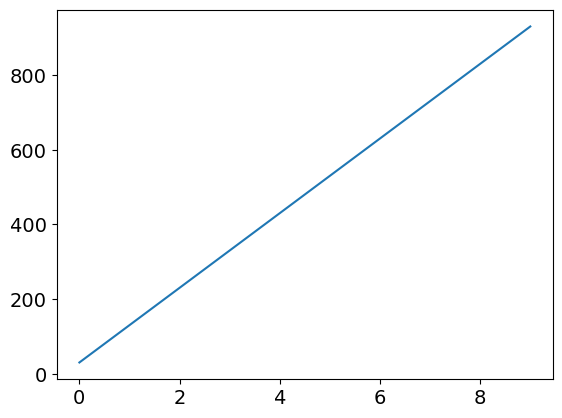

In [105]:
plt.plot(ells_rebinned)

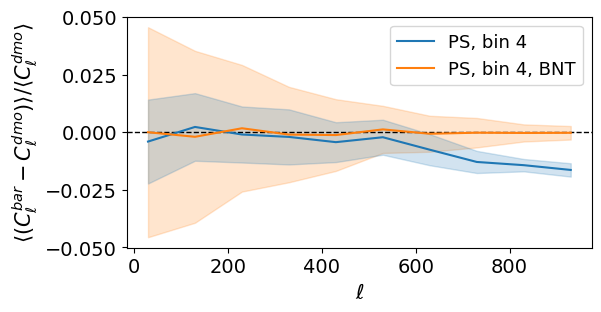

In [112]:
plt.figure(figsize=(6,3))

# change the size of the legend
plt.rcParams['legend.fontsize'] = 13
# change the size of the axes labels
plt.rcParams['axes.labelsize'] = 15
# change the size of the ticks
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.fill_between(ells_rebinned, frac_diff4_bnt-std_fractional_diff_bin4_bnt, frac_diff4_bnt+std_fractional_diff_bin4_bnt, color='C1', alpha=0.2)
plt.fill_between(ells_rebinned, frac_diff4-std_fractional_diff_bin4, frac_diff4+std_fractional_diff_bin4, color='C0', alpha=0.2)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.plot(ells_rebinned, frac_diff4, label='PS, bin 4', color='C0')
plt.plot(ells_rebinned, frac_diff4_bnt, label='PS, bin 4, BNT', color='C1')
plt.xlabel(r'$\ell$')
# plt.ylabel(r'$\langle \Delta C_\ell \rangle / \langle C_\ell \rangle$')
plt.ylabel(r'$\langle (C_\ell^{bar} - C_\ell^{dmo})\rangle / \langle C_\ell^{dmo} \rangle$')
plt.legend()

# save figure as transparent pdf
plt.savefig('/home/tersenov/software/bar_impact/plots/frac_diff_bin4_bnt_vs_standard.pdf', transparent=True, bbox_inches='tight')

plt.show()

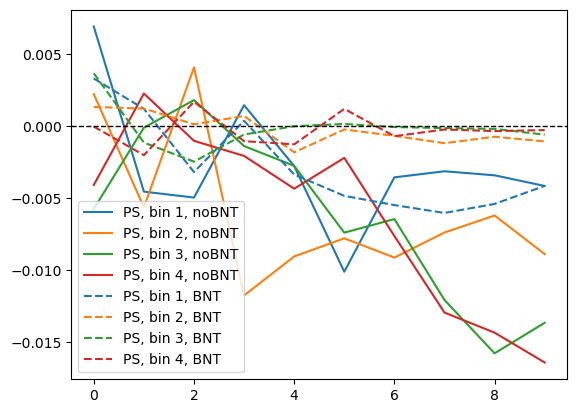

In [37]:
plt.plot(frac_diff1, label='PS, bin 1, noBNT', color='C0')
plt.plot(frac_diff2, label='PS, bin 2, noBNT', color='C1')
plt.plot(frac_diff3, label='PS, bin 3, noBNT', color='C2')
plt.plot(frac_diff4, label='PS, bin 4, noBNT', color='C3')

plt.plot(frac_diff1_bnt, label='PS, bin 1, BNT', linestyle='--', color='C0')
plt.plot(frac_diff2_bnt, label='PS, bin 2, BNT', linestyle='--', color='C1')
plt.plot(frac_diff3_bnt, label='PS, bin 3, BNT', linestyle='--', color='C2')
plt.plot(frac_diff4_bnt, label='PS, bin 4, BNT', linestyle='--', color='C3')

plt.axhline(0, color='black', linestyle='--', lw=1)
plt.legend()

In [39]:
fid_bar_bin1_l1.shape

(200, 5, 40)

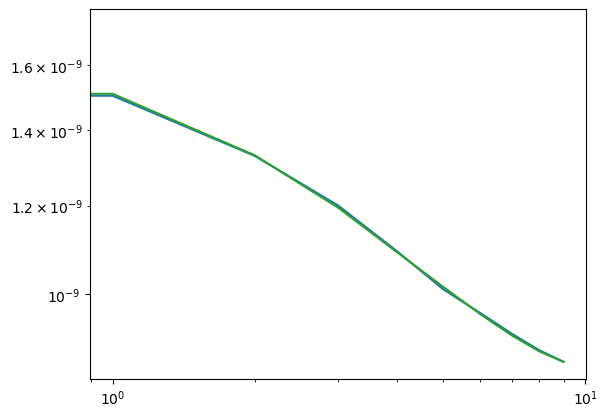

In [51]:
plt.loglog(np.mean(fid_bar_bin1, axis=0), label='PS, bin 1, bar', color='C0')
# plt.loglog(np.mean(fid_nobar_bin1, axis=0), label='PS, bin 1, nobar', linestyle='--', color='C1')

plt.loglog(np.mean(fid_bar_bin1_bnt, axis=0), label='PS, bin 1, bar, BNT', color='C2')
# plt.loglog(np.mean(fid_nobar_bin1_bnt, axis=0), label='PS, bin 1, nobar, BNT', linestyle='--', color='C3')

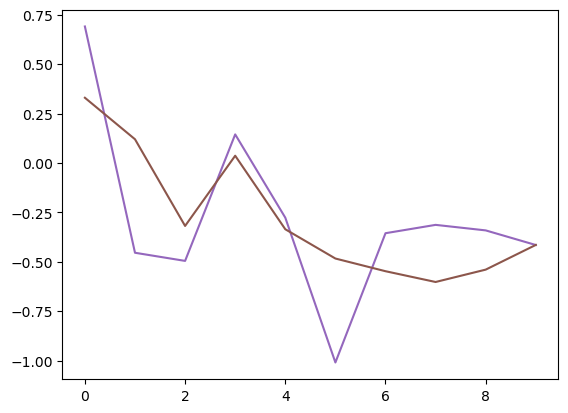

In [60]:
plt.plot(100*np.mean(fid_bar_bin1 - fid_nobar_bin1, axis=0)/np.mean(fid_nobar_bin1, axis=0), label='frac diff, bin 1, bar', color='C4')
plt.plot(100*np.mean(fid_bar_bin1_bnt - fid_nobar_bin1_bnt, axis=0)/np.mean(fid_nobar_bin1_bnt, axis=0), label='frac diff, bin 1, bar, BNT', color='C5')

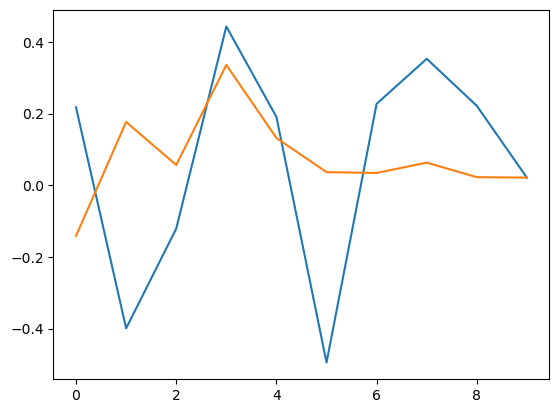

In [57]:
plt.plot(100*np.mean(fid_bar_bin1-fid_bar_bin1_bnt, axis=0)/np.mean(fid_bar_bin1, axis=0))
plt.plot(100*np.mean(fid_nobar_bin1-fid_nobar_bin1_bnt, axis=0)/np.mean(fid_nobar_bin1, axis=0))